# Gridded Race Analysis

Load up GPS data and convert GPS points to an array / grid of values instead of GPS.

In [1]:
file = '700_IL-203_S-2025-10-16_22-04-11.sqlite'

In [2]:
import sqlite3

# --- Configuration ---
DATABASE_FILE = "700_IL-203_S-2025-10-16_22-04-11.sqlite"
OUTPUT_FILE = "database_schema_summary.txt"
# ---------------------

def get_db_schema(db_file, output_file):
    """
    Connects to the SQLite database, extracts table and column names,
    and writes the information to a text file.
    """
    try:
        # Connect to the SQLite database (creates the file if it doesn't exist)
        conn = sqlite3.connect(db_file)
        cursor = conn.cursor()

        # Query to get all table names
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = [row[0] for row in cursor.fetchall()]

        schema_output = []
        schema_output.append(f"--- Database Schema for: {db_file} ---")

        if not tables:
            schema_output.append("\nNo tables found in the database.")
        else:
            for table_name in tables:
                schema_output.append(f"\nTABLE: {table_name}")
                schema_output.append("-" * (len(table_name) + 7))

                # Query to get column information for the current table
                cursor.execute(f"PRAGMA table_info({table_name});")
                columns = cursor.fetchall()
                
                # Column structure is: (cid, name, type, notnull, dflt_value, pk)
                for col in columns:
                    column_name = col[1]
                    column_type = col[2]
                    is_pk = " (PK)" if col[5] else ""
                    is_not_null = " NOT NULL" if col[3] else ""
                    
                    schema_output.append(f"  - {column_name} ({column_type}{is_not_null}{is_pk})")

        # Write the compiled schema to the output file
        with open(output_file, 'w') as f:
            f.write('\n'.join(schema_output))

        print(f"✅ Success! Schema saved to '{output_file}'")

    except sqlite3.Error as e:
        print(f"❌ SQLite Error: {e}")
    except Exception as e:
        print(f"❌ An unexpected error occurred: {e}")
    finally:
        # Close the connection
        if 'conn' in locals() and conn:
            conn.close()

# Execute the function
get_db_schema(DATABASE_FILE, OUTPUT_FILE)

✅ Success! Schema saved to 'database_schema_summary.txt'


In [3]:
import sqlite3
import pandas as pd

# --- Configuration ---
DATABASE_FILE = "700_IL-203_S-2025-10-16_22-04-11.sqlite"
TABLE_NAME = "Location" 
# ---------------------

try:
    # 1. Connect to the SQLite database
    conn = sqlite3.connect(DATABASE_FILE)
    
    # 2. Use a SQL query to load the entire table into a pandas DataFrame
    sql_query = f"SELECT * FROM {TABLE_NAME}"
    location_df = pd.read_sql_query(sql_query, conn)
    
    # 3. Print the head of the DataFrame
    print(f"✅ Successfully loaded table '{TABLE_NAME}' into a DataFrame.")
    print("\nDataFrame Head:")
    print(location_df.head())
    
except sqlite3.OperationalError as e:
    print(f"❌ Error: Could not load the table. Check if the file is present and the table '{TABLE_NAME}' exists.")
    print(f"Details: {e}")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")
finally:
    # 4. Close the connection
    if 'conn' in locals() and conn:
        conn.close()

✅ Successfully loaded table 'Location' into a DataFrame.

DataFrame Head:
                  time  seconds_elapsed    altitude  speedAccuracy  \
0  1760652250323972000        -1.136028   93.988842          -1.00   
1  1760652251682904000         0.222904   93.988842          -1.00   
2  1760652254678450700         3.218451  104.580505           1.73   
3  1760652255001453800         3.541454   92.824402           6.90   
4  1760652256001456400         4.541456   92.524292           1.14   

   bearingAccuracy   latitude  altitudeAboveMeanSeaLevel    bearing  \
0        -1.000000  38.648869                 126.104347  -1.000000   
1        -1.000000  38.648869                 126.104347  -1.000000   
2        48.452747  38.648734                 136.696011  20.390625   
3        39.759470  38.648711                 124.939907  20.390625   
4        -1.000000  38.648686                 124.639797  -1.000000   

   horizontalAccuracy  verticalAccuracy  longitude  speed  \
0           24.97

In [7]:
import numpy as np
import pandas as pd

# Assuming location_df is the DataFrame loaded in the previous step
# Replace placeholder values (-1.0) with NaN
location_df_clean = location_df.replace(-1.0, np.nan)

# Drop rows where essential coordinates are missing (NaN)
# You need valid lat/lon to transform the point
location_df_clean.dropna(subset=['latitude', 'longitude'], inplace=True)

# Optional: Apply accuracy filter (e.g., horizontalAccuracy <= 20 meters)
location_df_clean = location_df_clean[location_df_clean['horizontalAccuracy'] <= 20]

# IMPORTANT: Reset the index after dropping rows
location_df_clean.reset_index(drop=True, inplace=True)

In [8]:
import utm

# Function to convert Lat/Lon to UTM
def to_utm(row):
    # utm.from_latlon returns (easting, northing, zone_number, zone_letter)
    easting, northing, zone_num, zone_let = utm.from_latlon(row['latitude'], row['longitude'])
    return pd.Series({'easting': easting, 'northing': northing, 'utm_zone': f'{zone_num}{zone_let}'})

# Apply the conversion
location_df_clean[['easting', 'northing', 'utm_zone']] = location_df_clean.apply(to_utm, axis=1)

print("UTM Conversion Complete.")
print(location_df_clean[['latitude', 'longitude', 'easting', 'northing']].head())

UTM Conversion Complete.
    latitude  longitude        easting      northing
0  38.648711 -90.135438  749292.327492  4.281689e+06
1  38.648686 -90.135424  749293.700796  4.281686e+06
2  38.648688 -90.135460  749290.517909  4.281686e+06
3  38.648690 -90.135471  749289.605434  4.281686e+06
4  38.648687 -90.135462  749290.366850  4.281686e+06


In [9]:
# Find the minimum Easting (X-axis) and Northing (Y-axis) values
min_easting = location_df_clean['easting'].min()
min_northing = location_df_clean['northing'].min()

# Calculate the new local X and Y coordinates (in meters)
location_df_clean['grid_x'] = location_df_clean['easting'] - min_easting
location_df_clean['grid_y'] = location_df_clean['northing'] - min_northing

# The bottom-left point will now be (0, 0)
print("\nLocal Grid Transformation Complete.")
print("Grid Origin (m):", min_easting, min_northing)
print(location_df_clean[['easting', 'northing', 'grid_x', 'grid_y']].head())


Local Grid Transformation Complete.
Grid Origin (m): 749271.7711109841 4281609.72488837
         easting      northing     grid_x     grid_y
0  749292.327492  4.281689e+06  20.556381  79.003166
1  749293.700796  4.281686e+06  21.929685  76.233667
2  749290.517909  4.281686e+06  18.746798  76.367079
3  749289.605434  4.281686e+06  17.834323  76.565837
4  749290.366850  4.281686e+06  18.595739  76.278517


In [ ]:
# ASSUME: location_df_clean contains 'easting', 'northing', and 'seconds_elapsed'

import numpy as np
import pandas as pd

# Define generous, non-physical thresholds
MAX_SPEED_MPS = 150.0  # Max Speed: 150 m/s (approx 335 mph or 540 km/h)
MAX_ACCEL_MPSS = 100.0 # Max Acceleration: 100 m/s/s (approx 10 Gs)

def filter_teleportation_jumps(df):
    """
    Calculates velocity and acceleration between points and filters out segments
    exceeding defined physical limits.
    """
    # Shifted columns to align point N with point N-1 data
    df['prev_easting'] = df['easting'].shift(1)
    df['prev_northing'] = df['northing'].shift(1)
    df['prev_time'] = df['seconds_elapsed'].shift(1)

    # 1. Calculate distance (m) and time difference (s)
    df['delta_x'] = df['easting'] - df['prev_easting']
    df['delta_y'] = df['northing'] - df['prev_northing']
    df['delta_t'] = df['seconds_elapsed'] - df['prev_time']
    
    # Calculate segment distance using Pythagorean theorem (Euclidean distance on UTM)
    df['segment_distance'] = np.sqrt(df['delta_x']**2 + df['delta_y']**2)
    
    # 2. Calculate instantaneous speed (m/s)
    # Handle division by zero/near-zero time difference, which can occur if two points have the same timestamp
    df['speed_calc'] = df['segment_distance'] / df['delta_t'].replace(0, np.nan) 

    # 3. Filter the extreme speed outliers
    # The first point (index 0) will have NaN values; keep it for now.
    
    # Create a mask: True for points that are NOT outliers
    # Outliers are points that have impossible calculated speed
    is_not_speed_outlier = (df['speed_calc'] < MAX_SPEED_MPS) | df['speed_calc'].isna()
    
    # Apply the mask, keeping only physically plausible points
    df_filtered = df[is_not_speed_outlier].copy()
    
    # Clean up the temporary calculation columns
    cols_to_drop = ['prev_easting', 'prev_northing', 'prev_time', 'delta_x', 'delta_y', 'delta_t', 'segment_distance', 'speed_calc']
    df_filtered.drop(columns=cols_to_drop, inplace=True)
    df_filtered.reset_index(drop=True, inplace=True)
    
    print(f"Removed {len(df) - len(df_filtered)} points due to excessive speed.")
    return df_filtered

# Apply the filter to the data *before* lap segmentation
# NOTE: You should use this *instead* of your previous 'calculate_distance' step,
# and then re-run the Start/Finish line conversion and filtering steps.
location_df_clean = filter_teleportation_jumps(location_df_clean)

In [ ]:
from scipy.interpolate import interp1d

# Define the spacing for your analysis grid (e.g., every 0.1 meters)
GRID_SPACING = 0.1 

# The total length of the circuit/trace
total_distance = location_df_clean['cumulative_distance'].max()

# Create the new distance grid (e.g., 0.0, 0.1, 0.2, 0.3, ..., total_distance)
new_distance_grid = np.arange(0, total_distance, GRID_SPACING)

# Use interpolation to find the X and Y coordinates at each new distance point
x_interp = interp1d(location_df_clean['cumulative_distance'], location_df_clean['grid_x'])
y_interp = interp1d(location_df_clean['cumulative_distance'], location_df_clean['grid_y'])

grid_x_values = x_interp(new_distance_grid)
grid_y_values = y_interp(new_distance_grid)

# Create the final analysis DataFrame
analysis_grid_df = pd.DataFrame({
    'distance_m': new_distance_grid,
    'grid_x': grid_x_values,
    'grid_y': grid_y_values
})

print("\n--- Final Analysis Grid Head ---")
print(f"Total points generated: {len(analysis_grid_df)}")
print(analysis_grid_df.head())

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assuming your final DataFrame from the previous steps is named 'analysis_grid_df'
# It should contain 'grid_x' and 'grid_y' columns.

# --- Configuration ---
# Choose a subset to plot for performance/clarity, though the full grid is fine.
# We'll plot every 10th point if the grid is very dense (e.g., 0.1m spacing)
plot_df = analysis_grid_df.iloc[::10]
# ---------------------

def visualize_race_trace(df):
    """
    Plots the non-GPS race trace using the transformed grid_x and grid_y coordinates.
    """
    if df.empty:
        print("❌ The DataFrame is empty. Check your data cleaning/gridding steps.")
        return

    # Set a clean plotting style
    sns.set_style("whitegrid")
    
    plt.figure(figsize=(10, 8))
    
    # 1. Plot the main trace
    plt.plot(
        df['grid_x'], 
        df['grid_y'], 
        label='Race Trace', 
        color='#1f77b4', 
        linewidth=2, 
        alpha=0.7
    )
    
    # 2. Mark the Start/Finish Line (Origin)
    # The first point in the trace should be (0, 0)
    start_x = df['grid_x'].iloc[0]
    start_y = df['grid_y'].iloc[0]
    plt.scatter(
        start_x, 
        start_y, 
        color='green', 
        s=150, 
        marker='*', 
        edgecolor='black',
        zorder=5,
        label='Start/Origin (0, 0)'
    )
    
    # 3. Mark the End Point
    end_x = df['grid_x'].iloc[-1]
    end_y = df['grid_y'].iloc[-1]
    plt.scatter(
        end_x, 
        end_y, 
        color='red', 
        s=100, 
        marker='X', 
        zorder=5,
        label='End Point'
    )
    
    # 4. Set plot aesthetics
    plt.title('Non-GPS Race Trace on Local Cartesian Grid', fontsize=16)
    plt.xlabel('Grid X (Meters from Origin)', fontsize=12)
    plt.ylabel('Grid Y (Meters from Origin)', fontsize=12)
    
    # Ensure the axes have the same scale (crucial for map viewing!)
    plt.gca().set_aspect('equal', adjustable='box')
    
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_race_trace(plot_df)

In [ ]:
import utm
import numpy as np
import pandas as pd
from geopy.distance import geodesic # geopy is fine for this single conversion

# ASSUME: location_df_clean, min_easting, and min_northing exist from previous steps

# 1. Define the GPS coordinates for the S/F line
sf_gps = [
    (38.64886, -90.13461),  # P1 (Lat, Lon)
    (38.64888, -90.13440)   # P2 (Lat, Lon)
]

sf_grid_coords = []
for lat, lon in sf_gps:
    # Convert GPS to UTM
    easting, northing, _, _ = utm.from_latlon(lat, lon)
    
    # Apply the same shift to get Grid_X and Grid_Y
    grid_x = easting - min_easting
    grid_y = northing - min_northing
    sf_grid_coords.append((grid_x, grid_y))

# Unpack the two points for easier use
sf_p1_x, sf_p1_y = sf_grid_coords[0]
sf_p2_x, sf_p2_y = sf_grid_coords[1]

print("Start/Finish Line Grid Coordinates:")
print(f"P1 (Grid_X, Grid_Y): ({sf_p1_x:.2f}, {sf_p1_y:.2f})")
print(f"P2 (Grid_X, Grid_Y): ({sf_p2_x:.2f}, {sf_p2_y:.2f})")


In [ ]:
def check_crossing(p_prev, p_curr, sf_p1, sf_p2):
    """
    Checks if the segment (p_prev -> p_curr) intersects the S/F line segment (sf_p1 -> sf_p2).
    """
    
    # 2D Cross Product (Orientation Function)
    def orientation(p, q, r):
        val = (q[1] - p[1]) * (r[0] - q[0]) - (q[0] - p[0]) * (r[1] - q[1])
        if val == 0: return 0  # Collinear
        return 1 if val > 0 else 2 # Clockwise or Counterclockwise

    # Check the four orientations needed for general segment intersection
    o1 = orientation(sf_p1, sf_p2, p_prev)
    o2 = orientation(sf_p1, sf_p2, p_curr)
    o3 = orientation(p_prev, p_curr, sf_p1)
    o4 = orientation(p_prev, p_curr, sf_p2)

    # General case: segments cross
    if o1 != 0 and o2 != 0 and o3 != 0 and o4 != 0 and o1 != o2 and o3 != o4:
        return True
    
    # Edge cases (not typically needed for well-spaced GPS data, but good practice):
    # Check for collinearity and end-point overlap
    
    return False

# Convert analysis_grid_df back to DataFrame if needed, 
# or ensure it's the current DataFrame (let's use location_df_clean for raw points)
df = location_df_clean[['grid_x', 'grid_y']].copy()
sf_p1 = (sf_p1_x, sf_p1_y)
sf_p2 = (sf_p2_x, sf_p2_y)

crossing_indices = []
# Iterate through the DataFrame starting from the second point
for i in range(1, len(df)):
    p_prev = (df.iloc[i-1]['grid_x'], df.iloc[i-1]['grid_y'])
    p_curr = (df.iloc[i]['grid_x'], df.iloc[i]['grid_y'])
    
    if check_crossing(p_prev, p_curr, sf_p1, sf_p2):
        # We save the index of the *second* point of the crossing segment (p_curr)
        crossing_indices.append(i)

print(f"\nFound {len(crossing_indices)} S/F line crossings.")

In [ ]:
if len(crossing_indices) < 2:
    print("❌ WARNING: Less than two crossings found. Data may not contain a complete lap.")
else:
    # The first index marks the start of the *first* complete lap (after the first crossing)
    first_index = crossing_indices[0] 
    
    # The last index marks the end of the *last* complete lap (the last recorded point before the final crossing)
    last_index = crossing_indices[-1]

    # Filter the original clean DataFrame (location_df_clean)
    lap_data_trimmed = location_df_clean.iloc[first_index : last_index + 1].copy()
    
    print(f"\nOriginal points: {len(location_df_clean)}")
    print(f"Trimmed points (Full Laps Only): {len(lap_data_trimmed)}")
    
    # Now, reset the index for the trimmed data
    lap_data_trimmed.reset_index(drop=True, inplace=True)
    
    # The 'crossing_indices' list, when re-run on the trimmed data, will define your 12 individual laps!

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ASSUME: lap_data_trimmed DataFrame exists from the previous filtering step.
# ASSUME: sf_p1_x, sf_p1_y, sf_p2_x, sf_p2_y exist for the S/F line coordinates.

def plot_trimmed_trace(df, sf_p1_x, sf_p1_y, sf_p2_x, sf_p2_y):
    """
    Plots the filtered race trace and marks the defined Start/Finish line.
    """
    if df.empty:
        print("❌ The trimmed DataFrame is empty. Check your S/F line crossing logic.")
        return

    sns.set_style("whitegrid")
    
    plt.figure(figsize=(10, 8))
    
    # 1. Plot the trimmed race trace (all laps)
    plt.plot(
        df['grid_x'], 
        df['grid_y'], 
        label='Trimmed Race Trace (All Laps)', 
        color='#1f77b4', 
        linewidth=1.5, # Slightly thinner line to show individual laps better
        alpha=0.6
    )
    
    # 2. Plot the Start/Finish Line
    plt.plot(
        [sf_p1_x, sf_p2_x],  # X coordinates
        [sf_p1_y, sf_p2_y],  # Y coordinates
        color='black', 
        linestyle='--', 
        linewidth=3, 
        label='S/F Line (Timing)'
    )
    
    # 3. Mark the true Start of the first full lap
    # This should be the first point in the trimmed DataFrame
    plt.scatter(
        df['grid_x'].iloc[0], 
        df['grid_y'].iloc[0], 
        color='green', 
        s=150, 
        marker='*', 
        edgecolor='black',
        zorder=5,
        label='Start (First Crossing)'
    )
    
    # 4. Set plot aesthetics
    plt.title('Filtered Race Trace with Defined Start/Finish Line', fontsize=16)
    plt.xlabel('Grid X (Meters from Origin)', fontsize=12)
    plt.ylabel('Grid Y (Meters from Origin)', fontsize=12)
    
    # Ensure axes are equally scaled
    plt.gca().set_aspect('equal', adjustable='box')
    
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Execute the visualization
plot_trimmed_trace(lap_data_trimmed, sf_p1_x, sf_p1_y, sf_p2_x, sf_p2_y)

In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import utm
import matplotlib.pyplot as plt
import seaborn as sns
from geopy.distance import geodesic 

# --- CONFIGURATION (ADJUSTED FOR KART) ---
DATABASE_FILE = "700_IL-203_S-2025-10-16_22-04-11.sqlite"
TABLE_NAME = "Location"

SF_GPS_P1 = (38.64886, -90.13461)
SF_GPS_P2 = (38.64888, -90.13440)

# Cleaning Thresholds (Kart-Specific)
MAX_HORIZONTAL_ACCURACY = 10.0   # Tighter accuracy filter
MAX_PHYSICAL_SPEED_MPS = 30.0    # 30 m/s is approx 67 mph (limits teleportation)
MIN_SPEED_MPS = 2.5              # 2.5 m/s is approx 5.6 mph (removes stationary/spin noise)
MAX_ACCEL_MPSS = 50.0            # Max G-Force filter (50 m/s/s is approx 5 Gs)
# ------------------------------------------

# Global variables for UTM origin shift
min_easting = None
min_northing = None


# --- 1. DATA LOADING AND INITIAL CLEANING ---
try:
    # Load data from SQLite to Pandas DataFrame
    conn = sqlite3.connect(DATABASE_FILE)
    sql_query = f"SELECT * FROM {TABLE_NAME}"
    location_df = pd.read_sql_query(sql_query, conn)
    conn.close()

    # Initial Data Cleaning
    print("Step 1: Data Loading and Initial Cleaning...")
    location_df_clean = location_df.replace(-1.0, np.nan).copy()

    required_cols = ['latitude', 'longitude', 'horizontalAccuracy', 'seconds_elapsed']
    location_df_clean.dropna(subset=required_cols, inplace=True)

    # Filter out points with poor GPS accuracy
    location_df_clean = location_df_clean[
        location_df_clean['horizontalAccuracy'] <= MAX_HORIZONTAL_ACCURACY
    ].copy()
    
    location_df_clean.reset_index(drop=True, inplace=True)
    print(f"   -> Cleaned points: {len(location_df_clean)}.")

except Exception as e:
    print(f"❌ ERROR in Step 1 (Loading/Cleaning): {e}")
    exit()


# --- 2. GPS TO LOCAL GRID TRANSFORMATION (UTM) ---

def to_utm(row):
    easting, northing, _, _ = utm.from_latlon(row['latitude'], row['longitude'])
    return pd.Series({'easting': easting, 'northing': northing})

print("\nStep 2: Transforming GPS to Local Grid (UTM)...")
location_df_clean[['easting', 'northing']] = location_df_clean.apply(to_utm, axis=1)

min_easting = location_df_clean['easting'].min()
min_northing = location_df_clean['northing'].min()

location_df_clean['grid_x'] = location_df_clean['easting'] - min_easting
location_df_clean['grid_y'] = location_df_clean['northing'] - min_northing


# --- 3. FILTERING TELEPORTATION AND STATIONARY JUMPS (KART-SPECIFIC) ---

def filter_teleportation_jumps_v3(df):
    """
    Calculates velocity and acceleration and filters based on MAX/MIN_SPEED and MAX_ACCEL.
    """
    df_temp = df.copy()

    # Calculate Speed (V1)
    df_temp['prev_easting'] = df_temp['easting'].shift(1)
    df_temp['prev_northing'] = df_temp['northing'].shift(1)
    df_temp['prev_time'] = df_temp['seconds_elapsed'].shift(1)
    df_temp['delta_t'] = df_temp['seconds_elapsed'] - df_temp['prev_time']
    df_temp['segment_distance'] = np.sqrt(
        (df_temp['easting'] - df_temp['prev_easting'])**2 + 
        (df_temp['northing'] - df_temp['prev_northing'])**2
    )
    df_temp['speed_calc'] = df_temp['segment_distance'] / df_temp['delta_t'].replace(0, np.nan) 

    # Calculate Acceleration (A)
    df_temp['prev_speed'] = df_temp['speed_calc'].shift(1)
    df_temp['delta_v'] = df_temp['speed_calc'] - df_temp['prev_speed']
    df_temp['accel_calc'] = df_temp['delta_v'] / df_temp['delta_t'].shift(1).replace(0, np.nan)
    
    # 1. Speed Filter Mask
    is_valid_speed = (df_temp['speed_calc'] < MAX_PHYSICAL_SPEED_MPS) & \
                     (df_temp['speed_calc'] > MIN_SPEED_MPS)

    # 2. Acceleration Filter Mask
    is_valid_accel = (df_temp['accel_calc'].abs() < MAX_ACCEL_MPSS) | df_temp['accel_calc'].isna()
    
    # Final Mask: Keep valid moving points OR the first two points
    is_valid_point = (is_valid_speed & is_valid_accel) | (df_temp.index < 2)
    
    df_filtered = df_temp[is_valid_point].copy()
    
    removed_count = len(df) - len(df_filtered)
    
    # Clean up and return
    cols_to_drop = [col for col in df_filtered.columns if col not in df.columns]
    df_filtered.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    df_filtered.reset_index(drop=True, inplace=True)
    
    print(f"\nStep 3: Filtering Jumps/Noise (Kart Limits)...")
    print(f"   -> Removed {removed_count} points due to non-physical movement (Speed/Accel).")
    return df_filtered

location_df_clean = filter_teleportation_jumps_v3(location_df_clean)


# --- 4. LAP SEGMENTATION SETUP (Defining and Trimming to S/F Line) ---

# Convert S/F GPS points to Grid_X/Grid_Y
sf_grid_coords = []
for lat, lon in [SF_GPS_P1, SF_GPS_P2]:
    easting, northing, _, _ = utm.from_latlon(lat, lon)
    grid_x = easting - min_easting
    grid_y = northing - min_northing
    sf_grid_coords.append((grid_x, grid_y))

sf_p1_x, sf_p1_y = sf_grid_coords[0]
sf_p2_x, sf_p2_y = sf_grid_coords[1]
sf_p1 = (sf_p1_x, sf_p1_y)
sf_p2 = (sf_p2_x, sf_p2_y)

print("\nStep 4: Lap Segmentation and Trimming...")

# Function to check for line segment crossing
def check_crossing(p_prev, p_curr, sf_p1, sf_p2):
    def orientation(p, q, r):
        val = (q[1] - p[1]) * (r[0] - q[0]) - (q[0] - p[0]) * (r[1] - q[1])
        if val == 0: return 0
        return 1 if val > 0 else 2

    o1 = orientation(sf_p1, sf_p2, p_prev)
    o2 = orientation(sf_p1, sf_p2, p_curr)
    o3 = orientation(p_prev, p_curr, sf_p1)
    o4 = orientation(p_prev, p_curr, sf_p2)

    return o1 != 0 and o2 != 0 and o3 != 0 and o4 != 0 and o1 != o2 and o3 != o4

# Find all crossing points in the cleaned trace
crossing_indices = []
for i in range(1, len(location_df_clean)):
    p_prev = (location_df_clean.iloc[i-1]['grid_x'], location_df_clean.iloc[i-1]['grid_y'])
    p_curr = (location_df_clean.iloc[i]['grid_x'], location_df_clean.iloc[i]['grid_y'])
    
    if check_crossing(p_prev, p_curr, sf_p1, sf_p2):
        crossing_indices.append(i)

# Trim data to the first and last complete crossing
if len(crossing_indices) < 2:
    print("   -> WARNING: Less than two crossings found. Cannot segment laps.")
    lap_data_trimmed = location_df_clean.copy() 
else:
    first_index = crossing_indices[0] 
    last_index = crossing_indices[-1]

    lap_data_trimmed = location_df_clean.iloc[first_index : last_index + 1].copy()
    lap_data_trimmed.reset_index(drop=True, inplace=True)
    print(f"   -> Found {len(crossing_indices)} S/F crossings.")
    print(f"   -> Trimmed trace contains {len(lap_data_trimmed)} points.")


# --- 5. VISUALIZATION OF THE CLEANED AND TRIMMED TRACE ---

def plot_final_trace(df, sf_x1, sf_y1, sf_x2, sf_y2):
    """Plots the filtered and trimmed race trace with the S/F line marked."""
    sns.set_style("whitegrid")
    
    plt.figure(figsize=(8, 10))
    
    # Plot the trimmed race trace (all laps)
    # The number of laps is 1 less than the number of crossings
    num_laps = len(crossing_indices) - 1 if len(crossing_indices) >= 2 else 0
    plt.plot(
        df['grid_x'], 
        df['grid_y'], 
        label=f'Trimmed Race Trace ({num_laps} Laps)', 
        color='#1f77b4', 
        linewidth=1.5, 
        alpha=0.6
    )
    
    # Plot the Start/Finish Line
    plt.plot(
        [sf_x1, sf_x2], [sf_y1, sf_y2], 
        color='black', 
        linestyle='--', 
        linewidth=3, 
        label='S/F Line (Timing)'
    )
    
    # Mark the true Start/End Points
    plt.scatter(df['grid_x'].iloc[0], df['grid_y'].iloc[0], color='green', s=150, marker='*', edgecolor='black', zorder=5, label='Start (First Data Point)')
    plt.scatter(df['grid_x'].iloc[-1], df['grid_y'].iloc[-1], color='red', s=100, marker='X', zorder=5, label='End Point')
    
    # Set plot aesthetics
    plt.title('Cleaned and Trimmed Race Trace on Local Grid', fontsize=16)
    plt.xlabel('Grid X (Meters from Origin)', fontsize=12)
    plt.ylabel('Grid Y (Meters from Origin)', fontsize=12)
    plt.gca().set_aspect('equal', adjustable='box')
    
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

print("\nStep 5: Visualizing the Final Cleaned Trace...")
plot_final_trace(lap_data_trimmed, sf_p1_x, sf_p1_y, sf_p2_x, sf_p2_y)

In [ ]:
# Rerun the speed calculation logic without filtering, just for inspection

df = location_df_clean.copy() 

# Shifted columns to align point N with point N-1 data
df['prev_easting'] = df['easting'].shift(1)
df['prev_northing'] = df['northing'].shift(1)
df['prev_time'] = df['seconds_elapsed'].shift(1)

# 1. Calculate distance (m) and time difference (s)
df['delta_x'] = df['easting'] - df['prev_easting']
df['delta_y'] = df['northing'] - df['prev_northing']
df['delta_t'] = df['seconds_elapsed'] - df['prev_time']

# Calculate segment distance using Pythagorean theorem (Euclidean distance on UTM)
df['segment_distance'] = np.sqrt(df['delta_x']**2 + df['delta_y']**2)

# 2. Calculate instantaneous speed (m/s)
df['speed_calc'] = df['segment_distance'] / df['delta_t'].replace(0, np.nan) 

# --- INSPECTION STEP ---
# Find the rows with the highest calculated speed
# This should quickly identify the teleportation jumps
print("Top 5 Calculated Speeds (likely jump points):")
print(df.sort_values(by='speed_calc', ascending=False)[['grid_x', 'grid_y', 'segment_distance', 'delta_t', 'speed_calc']].head())

In [ ]:
import pandas as pd

# Assuming location_df_clean is the DataFrame after Step 2 (UTM conversion)
# but before Step 3 (the last, problematic filter).
# We need the columns: grid_x, grid_y, seconds_elapsed, utc_time

# --- A. Define the Bounding Box for the Anomaly (Visual Estimation) ---
# Define a range that captures the jump and the clean track around it.
X_MIN = 60
X_MAX = 110
Y_MIN = 100
Y_MAX = 220

# Filter the DataFrame to the area of the jump
anomaly_segment = location_df_clean[
    (location_df_clean['grid_x'] >= X_MIN) & 
    (location_df_clean['grid_x'] <= X_MAX) & 
    (location_df_clean['grid_y'] >= Y_MIN) & 
    (location_df_clean['grid_y'] <= Y_MAX)
].copy()

# Sort by time to ensure we see the sequence of the jump
anomaly_segment.sort_values(by='seconds_elapsed', inplace=True)
anomaly_segment.reset_index(inplace=True, drop=False)

# --- B. Create Human-Readable Timestamp and Time Delta ---
# The 'utc_time' column (from your screenshot) is already a readable timestamp, 
# but let's confirm the time gap (delta_t)
anomaly_segment['prev_time'] = anomaly_segment['seconds_elapsed'].shift(1)
anomaly_segment['delta_t'] = anomaly_segment['seconds_elapsed'] - anomaly_segment['prev_time']
anomaly_segment['delta_dist'] = np.sqrt(
    (anomaly_segment['grid_x'] - anomaly_segment['grid_x'].shift(1))**2 + 
    (anomaly_segment['grid_y'] - anomaly_segment['grid_y'].shift(1))**2
)
anomaly_segment['calculated_speed'] = anomaly_segment['delta_dist'] / anomaly_segment['delta_t'].replace(0, np.nan)

# Select the key diagnostic columns
diag_cols = ['index', 'utc_time', 'delta_t', 'grid_x', 'grid_y', 'calculated_speed', 'horizontalAccuracy']
print("\n--- Diagnostic: Anomaly Jump Points (Look for high speed/low accuracy) ---")
print(anomaly_segment[diag_cols].head(20))

In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import utm
import matplotlib.pyplot as plt
import seaborn as sns
from geopy.distance import geodesic 

# --- CONFIGURATION (KART-SPECIFIC) ---
DATABASE_FILE = "700_IL-203_S-2025-10-16_22-04-11.sqlite"
TABLE_NAME = "Location"

# Start/Finish Line GPS (used for lap cutting)
SF_GPS_P1 = (38.64886, -90.13461)
SF_GPS_P2 = (38.64888, -90.13440)

# Cleaning Thresholds
MAX_HORIZONTAL_ACCURACY = 10.0   # Tighter accuracy filter (in meters)
MAX_PHYSICAL_SPEED_MPS = 30.0    # Max speed to filter out teleportation (m/s)
MIN_SPEED_MPS = 2.5              # Min speed to filter out stationary/spin noise (m/s)
MAX_ACCEL_MPSS = 50.0            # Max acceleration to filter non-physical jumps (m/s/s)
MAX_TIME_GAP_S = 2.0             # CRITICAL: Max time gap before a point is discarded (in seconds)
# ------------------------------------------

# Global variables for UTM origin shift
min_easting = None
min_northing = None

# --- 1. DATA LOADING AND INITIAL CLEANING ---
try:
    print("Step 1: Data Loading and Initial Cleaning...")
    conn = sqlite3.connect(DATABASE_FILE)
    location_df = pd.read_sql_query(f"SELECT * FROM {TABLE_NAME}", conn)
    conn.close()

    location_df_clean = location_df.replace(-1.0, np.nan).copy()

    required_cols = ['latitude', 'longitude', 'horizontalAccuracy', 'seconds_elapsed']
    location_df_clean.dropna(subset=required_cols, inplace=True)

    # Filter by required GPS accuracy
    location_df_clean = location_df_clean[
        location_df_clean['horizontalAccuracy'] <= MAX_HORIZONTAL_ACCURACY
    ].copy()
    
    location_df_clean.reset_index(drop=True, inplace=True)
    print(f"   -> Cleaned points: {len(location_df_clean)}.")

except Exception as e:
    print(f"❌ ERROR in Step 1 (Loading/Cleaning): {e}")
    exit()

# --- 2. GPS TO LOCAL GRID TRANSFORMATION (UTM) ---

def to_utm(row):
    easting, northing, _, _ = utm.from_latlon(row['latitude'], row['longitude'])
    return pd.Series({'easting': easting, 'northing': northing})

print("\nStep 2: Transforming GPS to Local Grid (UTM)...")
location_df_clean[['easting', 'northing']] = location_df_clean.apply(to_utm, axis=1)

min_easting = location_df_clean['easting'].min()
min_northing = location_df_clean['northing'].min()

# Create the final grid coordinates with the origin at the bottom-left
location_df_clean['grid_x'] = location_df_clean['easting'] - min_easting
location_df_clean['grid_y'] = location_df_clean['northing'] - min_northing


# --- 3. AGGRESSIVE FILTERING (Speed, Accel, TIME GAP) ---

def filter_teleportation_jumps_v5(df):
    """Filters based on all physical and recording limits, starting with NaN removal."""
    df_temp = df.copy()

    # CRITICAL: Drop rows where Easting, Northing, or Time are NaN (shouldn't happen here, but ensures integrity)
    critical_cols = ['easting', 'northing', 'seconds_elapsed']
    rows_before_drop = len(df_temp)
    df_temp.dropna(subset=critical_cols, inplace=True)
    rows_dropped = rows_before_drop - len(df_temp)
    df_temp.reset_index(drop=True, inplace=True)

    if rows_dropped > 0:
        print(f"   -> WARNING: Dropped {rows_dropped} rows with NaN in critical columns before filtering.")
        
    # Calculate Speed (V), Acceleration (A), and Delta Time (t)
    df_temp['prev_easting'] = df_temp['easting'].shift(1)
    df_temp['prev_northing'] = df_temp['northing'].shift(1)
    df_temp['prev_time'] = df_temp['seconds_elapsed'].shift(1)
    df_temp['delta_t'] = df_temp['seconds_elapsed'] - df_temp['prev_time']
    
    df_temp['segment_distance'] = np.sqrt(
        (df_temp['easting'] - df_temp['prev_easting'])**2 + 
        (df_temp['northing'] - df_temp['prev_northing'])**2
    )
    df_temp['speed_calc'] = df_temp['segment_distance'] / df_temp['delta_t'].replace(0, np.nan) 
    
    df_temp['prev_speed'] = df_temp['speed_calc'].shift(1)
    df_temp['delta_v'] = df_temp['speed_calc'] - df_temp['prev_speed']
    df_temp['accel_calc'] = df_temp['delta_v'] / df_temp['delta_t'].shift(1).replace(0, np.nan)
    
    # --- THE CRITICAL FILTER LOGIC (V5) ---

    # 1. TIME GAP FILTER: Removes the start-of-resume point after a long stop
    is_valid_time_gap = (df_temp['delta_t'] <= MAX_TIME_GAP_S)
    
    # 2. Speed and Acceleration Filters
    is_valid_speed = (df_temp['speed_calc'] < MAX_PHYSICAL_SPEED_MPS) & \
                     (df_temp['speed_calc'] > MIN_SPEED_MPS)
    is_valid_accel = (df_temp['accel_calc'].abs() < MAX_ACCEL_MPSS) | df_temp['accel_calc'].isna()
    
    # Final Mask: Must satisfy all 3 physical checks, OR be one of the first two points (start of trace)
    is_valid_point = (is_valid_speed & is_valid_accel & is_valid_time_gap) | (df_temp.index < 2)
    
    df_filtered = df_temp[is_valid_point].copy()
    
    removed_count = len(df) - len(df_filtered)
    
    # Clean up and return
    cols_to_drop = [col for col in df_filtered.columns if col not in df.columns]
    df_filtered.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    df_filtered.reset_index(drop=True, inplace=True)
    
    print(f"\nStep 3: Aggressive Filtering (Kart Limits & Time Gap)...")
    print(f"   -> Removed {removed_count} points due to non-physical movement or large time gaps.")
    return df_filtered

location_df_clean = filter_teleportation_jumps_v5(location_df_clean)


# --- 4. LAP SEGMENTATION SETUP (Defining and Trimming to S/F Line) ---

# Convert S/F GPS points to Grid_X/Grid_Y
sf_grid_coords = []
for lat, lon in [SF_GPS_P1, SF_GPS_P2]:
    easting, northing, _, _ = utm.from_latlon(lat, lon)
    grid_x = easting - min_easting
    grid_y = northing - min_northing
    sf_grid_coords.append((grid_x, grid_y))

sf_p1_x, sf_p1_y = sf_grid_coords[0]
sf_p2_x, sf_p2_y = sf_grid_coords[1]
sf_p1 = (sf_p1_x, sf_p1_y)
sf_p2 = (sf_p2_x, sf_p2_y)

print("\nStep 4: Lap Segmentation and Trimming...")

# Function to check for line segment crossing
def check_crossing(p_prev, p_curr, sf_p1, sf_p2):
    def orientation(p, q, r):
        val = (q[1] - p[1]) * (r[0] - q[0]) - (q[0] - p[0]) * (r[1] - q[1])
        if val == 0: return 0
        return 1 if val > 0 else 2

    o1 = orientation(sf_p1, sf_p2, p_prev)
    o2 = orientation(sf_p1, sf_p2, p_curr)
    o3 = orientation(p_prev, p_curr, sf_p1)
    o4 = orientation(p_prev, p_curr, sf_p2)

    return o1 != 0 and o2 != 0 and o3 != 0 and o4 != 0 and o1 != o2 and o3 != o4

# Find all crossing points in the cleaned trace
crossing_indices = []
for i in range(1, len(location_df_clean)):
    p_prev = (location_df_clean.iloc[i-1]['grid_x'], location_df_clean.iloc[i-1]['grid_y'])
    p_curr = (location_df_clean.iloc[i]['grid_x'], location_df_clean.iloc[i]['grid_y'])
    
    if check_crossing(p_prev, p_curr, sf_p1, sf_p2):
        crossing_indices.append(i)

# Trim data to the first and last complete crossing
if len(crossing_indices) < 2:
    print("   -> WARNING: Less than two crossings found. Cannot segment laps.")
    lap_data_trimmed = location_df_clean.copy() 
else:
    first_index = crossing_indices[0] 
    last_index = crossing_indices[-1]

    lap_data_trimmed = location_df_clean.iloc[first_index : last_index + 1].copy()
    lap_data_trimmed.reset_index(drop=True, inplace=True)
    print(f"   -> Found {len(crossing_indices)} S/F crossings.")
    print(f"   -> Trimmed trace contains {len(lap_data_trimmed)} points.")


# --- 5. VISUALIZATION OF THE CLEANED AND TRIMMED TRACE ---

def plot_final_trace(df, sf_x1, sf_y1, sf_x2, sf_y2):
    """Plots the filtered and trimmed race trace with the S/F line marked."""
    sns.set_style("whitegrid")
    
    plt.figure(figsize=(8, 10))
    
    # Plot the trimmed race trace (all laps)
    num_laps = len(crossing_indices) - 1 if len(crossing_indices) >= 2 else 0
    plt.plot(
        df['grid_x'], 
        df['grid_y'], 
        label=f'Trimmed Race Trace ({num_laps} Laps)', 
        color='#1f77b4', 
        linewidth=1.5, 
        alpha=0.6
    )
    
    # Plot the Start/Finish Line
    plt.plot(
        [sf_x1, sf_x2], [sf_y1, sf_y2], 
        color='black', 
        linestyle='--', 
        linewidth=3, 
        label='S/F Line (Timing)'
    )
    
    # Mark the true Start/End Points
    plt.scatter(df['grid_x'].iloc[0], df['grid_y'].iloc[0], color='green', s=150, marker='*', edgecolor='black', zorder=5, label='Start (First Data Point)')
    plt.scatter(df['grid_x'].iloc[-1], df['grid_y'].iloc[-1], color='red', s=100, marker='X', zorder=5, label='End Point')
    
    # Set plot aesthetics
    plt.title('Final Cleaned Race Trace on Local Grid (Time-Gap Filtered)', fontsize=16)
    plt.xlabel('Grid X (Meters from Origin)', fontsize=12)
    plt.ylabel('Grid Y (Meters from Origin)', fontsize=12)
    plt.gca().set_aspect('equal', adjustable='box')
    
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

print("\nStep 5: Visualizing the Final Cleaned Trace...")
plot_final_trace(lap_data_trimmed, sf_p1_x, sf_p1_y, sf_p2_x, sf_p2_y)

In [ ]:
# Assuming 'location_df_clean' is the DataFrame after UTM conversion (Step 2)

# --- Define the critical columns for movement analysis ---
CRITICAL_COLS = ['grid_x', 'grid_y', 'seconds_elapsed']

# Check for rows that contain ANY NaN value in the critical columns
nan_rows = location_df_clean[location_df_clean[CRITICAL_COLS].isnull().any(axis=1)]

print(f"Total NaN rows found in critical columns: {len(nan_rows)}")

if not nan_rows.empty:
    print("\nSample of rows containing NaN values:")
    # Display the first 10 rows with NaNs, showing the relevant columns
    print(nan_rows[CRITICAL_COLS].head(10))
else:
    print("No NaN values found in critical columns. The issue is likely due to the filter thresholds.")

Step 1: Data Loading and Initial Cleaning...
   -> Cleaned points: 904.

Step 2: Transforming GPS to Local Grid (UTM)...

Step 3: Aggressive Filtering Complete.
   -> Removed 5 points by Targeted Spatial filter (Top 5 segments).
   -> Removed 169 points by Time/Speed/Accel filter.

Step 4: Lap Segmentation and Trimming...
   -> Found 15 S/F crossings.
   -> Trimmed trace contains 653 points.
   -> Successfully segmented 14 individual laps.

Step 5: Visualizing the Final Composite Trace...


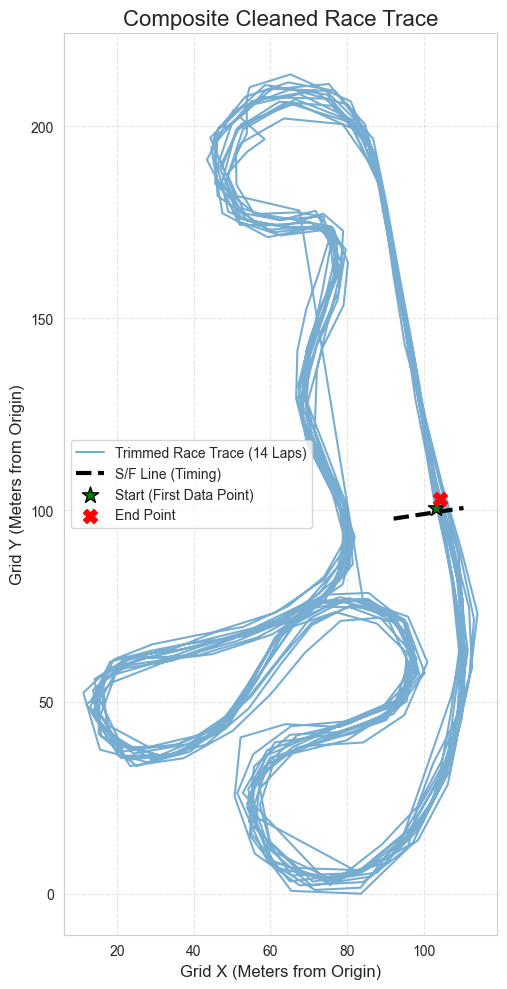


Step 6: Visualizing Individual Lap Traces...


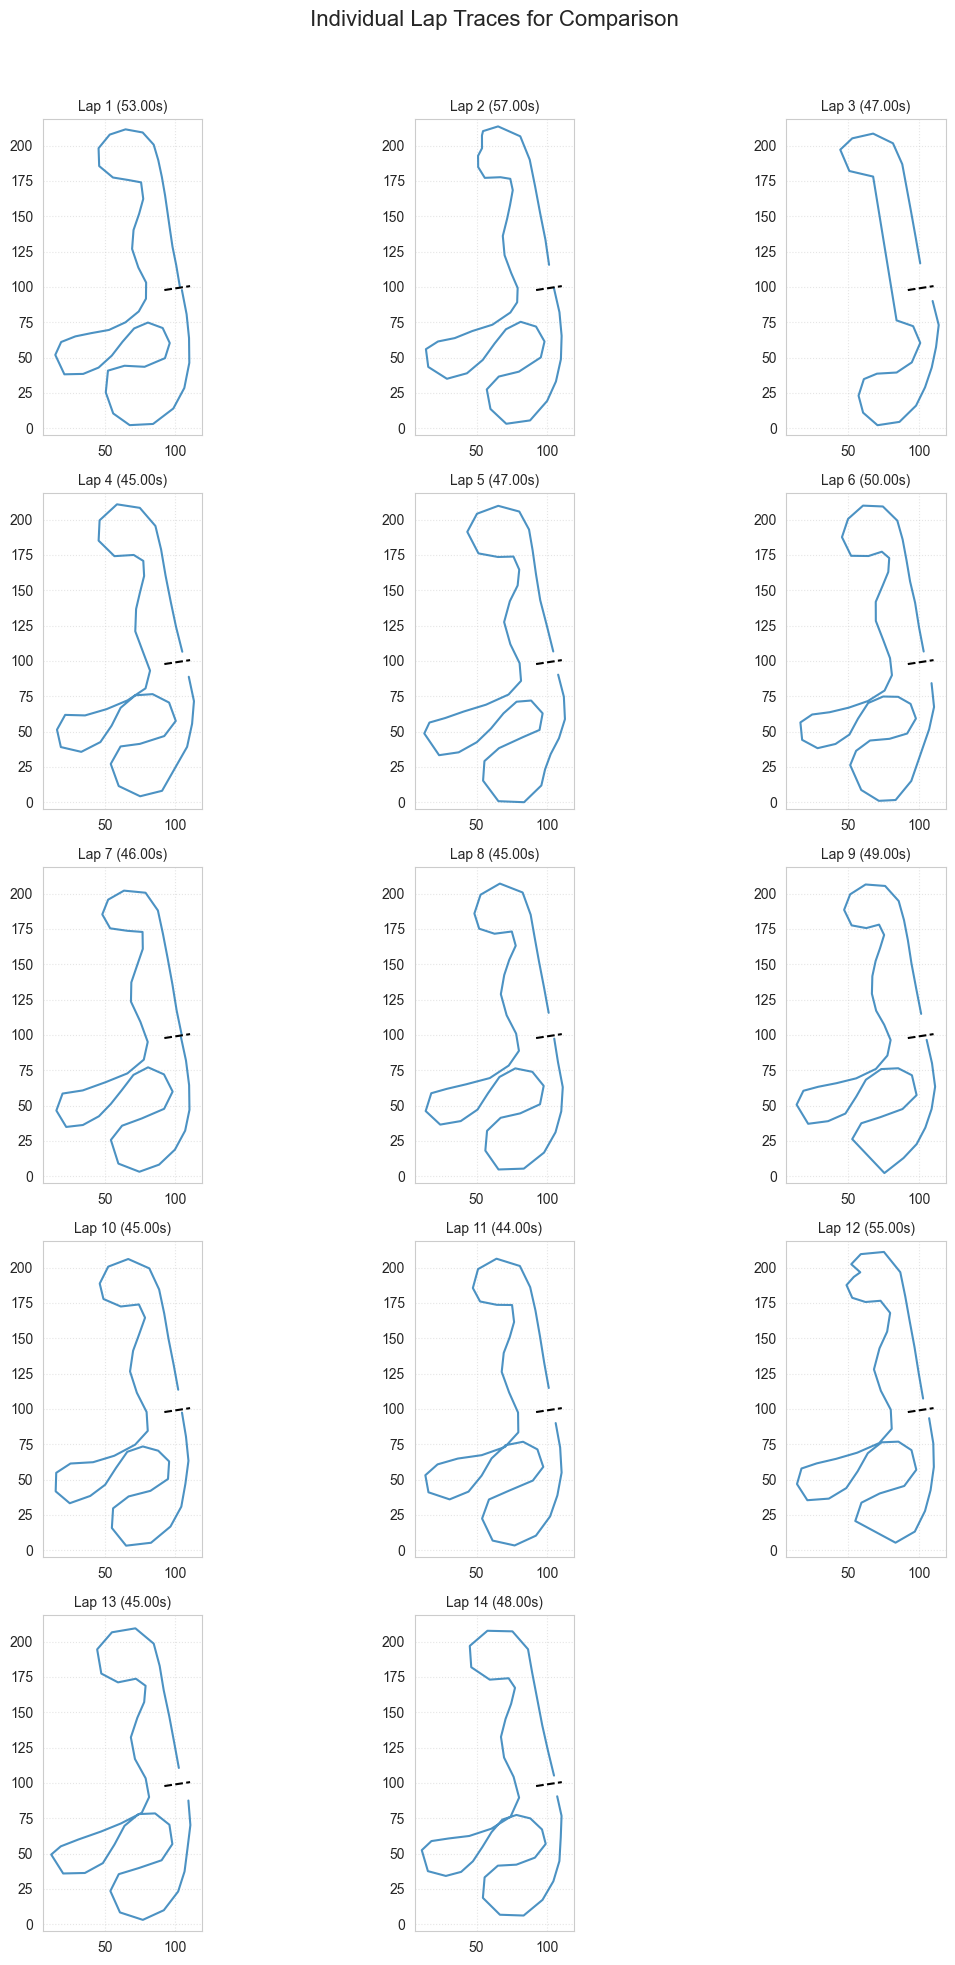

In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import utm
import matplotlib.pyplot as plt
import seaborn as sns
from geopy.distance import geodesic 

# --- CONFIGURATION (KART-SPECIFIC) ---
DATABASE_FILE = "700_IL-203_S-2025-10-16_22-04-11.sqlite"
TABLE_NAME = "Location"

# Start/Finish Line GPS (used for lap cutting)
SF_GPS_P1 = (38.64886, -90.13461)
SF_GPS_P2 = (38.64888, -90.13440)

# Cleaning Thresholds (ACCURATE KART LIMITS)
MAX_HORIZONTAL_ACCURACY = 10.0   # Tighter accuracy filter (in meters)
MAX_PHYSICAL_SPEED_MPS = 25.0    # **UPDATED: Max kart speed (~56 mph)**
MIN_SPEED_MPS = 2.5              # Min speed to filter out stationary/spin noise (m/s)
MAX_ACCEL_MPSS = 20.0            # **UPDATED: Max acceleration filter (~2 Gs)**
MAX_TIME_GAP_S = 2.0             # CRITICAL: Max time gap before a point is discarded (in seconds)
# ------------------------------------------

# Global variables for UTM origin shift
min_easting = None
min_northing = None
lap_dataframes = [] # NEW: List to store individual lap DataFrames

# --- 1. DATA LOADING AND INITIAL CLEANING ---
try:
    print("Step 1: Data Loading and Initial Cleaning...")
    conn = sqlite3.connect(DATABASE_FILE)
    location_df = pd.read_sql_query(f"SELECT * FROM {TABLE_NAME}", conn)
    conn.close()

    location_df_clean = location_df.replace(-1.0, np.nan).copy()

    required_cols = ['latitude', 'longitude', 'horizontalAccuracy', 'seconds_elapsed']
    location_df_clean.dropna(subset=required_cols, inplace=True)

    # Filter by required GPS accuracy
    location_df_clean = location_df_clean[
        location_df_clean['horizontalAccuracy'] <= MAX_HORIZONTAL_ACCURACY
    ].copy()
    
    location_df_clean.reset_index(drop=True, inplace=True)
    print(f"   -> Cleaned points: {len(location_df_clean)}.")

except Exception as e:
    print(f"❌ ERROR in Step 1 (Loading/Cleaning): {e}")
    exit()

# --- 2. GPS TO LOCAL GRID TRANSFORMATION (UTM) ---

def to_utm(row):
    easting, northing, _, _ = utm.from_latlon(row['latitude'], row['longitude'])
    return pd.Series({'easting': easting, 'northing': northing})

print("\nStep 2: Transforming GPS to Local Grid (UTM)...")
location_df_clean[['easting', 'northing']] = location_df_clean.apply(to_utm, axis=1)

min_easting = location_df_clean['easting'].min()
min_northing = location_df_clean['northing'].min()

# Create the final grid coordinates with the origin at the bottom-left
location_df_clean['grid_x'] = location_df_clean['easting'] - min_easting
location_df_clean['grid_y'] = location_df_clean['northing'] - min_northing


# --- 3. TARGETED SPATIAL FILTERING (Final Fix) ---

def filter_teleportation_jumps_final(df):
    """
    Applies targeted spatial filter (removes top N longest segments) 
    followed by time/speed filters.
    """
    df_temp = df.copy()
    
    # CRITICAL: Drop rows with NaN to ensure movement metrics are correct
    critical_cols = ['easting', 'northing', 'seconds_elapsed']
    df_temp.dropna(subset=critical_cols, inplace=True)
    df_temp.reset_index(drop=True, inplace=True)
    
    # 1. TARGETED SPATIAL REMOVAL (Remove the top 5 longest segments)
    
    # Calculate segment distance
    df_temp['prev_grid_x'] = df_temp['grid_x'].shift(1)
    df_temp['prev_grid_y'] = df_temp['grid_y'].shift(1)
    
    df_temp['segment_distance'] = np.sqrt(
        (df_temp['grid_x'] - df_temp['prev_grid_x'])**2 + 
        (df_temp['grid_y'] - df_temp['prev_grid_y'])**2
    )
    
    # Set the number of longest segments to remove (guarantees the jump is hit)
    N_TO_REMOVE = 5
    
    # Get the indices corresponding to the N largest distances
    largest_segments = df_temp.nlargest(N_TO_REMOVE, 'segment_distance')
    indices_to_drop = largest_segments.index.tolist()
    
    df_filtered = df_temp.drop(indices_to_drop).copy()
    removed_count_spatial = len(indices_to_drop)
    
    # 2. TIME & MOVEMENT FILTER (Standard physical limits on the spatially-cleaned data)

    # Clean up temporary columns before the next stage of calculation
    df_filtered.drop(columns=['prev_grid_x', 'prev_grid_y', 'segment_distance'], errors='ignore', inplace=True)
    df_filtered.reset_index(drop=True, inplace=True)
    
    # Recalculate movement metrics on the newly cleaned sequence
    df_filtered['prev_time'] = df_filtered['seconds_elapsed'].shift(1)
    df_filtered['delta_t'] = df_filtered['seconds_elapsed'] - df_filtered['prev_time']
    
    df_filtered['segment_distance'] = np.sqrt(
        (df_filtered['grid_x'] - df_filtered['grid_x'].shift(1))**2 + 
        (df_filtered['grid_y'] - df_filtered['grid_y'].shift(1))**2
    )

    df_filtered['speed_calc'] = df_filtered['segment_distance'] / df_filtered['delta_t'].replace(0, np.nan) 
    df_filtered['prev_speed'] = df_filtered['speed_calc'].shift(1)
    df_filtered['delta_v'] = df_filtered['speed_calc'] - df_filtered['prev_speed']
    df_filtered['accel_calc'] = df_filtered['delta_v'] / df_filtered['delta_t'].shift(1).replace(0, np.nan)
    
    # FILTER LOGIC
    is_valid_time_gap = (df_filtered['delta_t'] <= MAX_TIME_GAP_S)
    is_valid_speed = (df_filtered['speed_calc'] < MAX_PHYSICAL_SPEED_MPS) & \
                     (df_filtered['speed_calc'] > MIN_SPEED_MPS)
    is_valid_accel = (df_filtered['accel_calc'].abs() < MAX_ACCEL_MPSS) | df_filtered['accel_calc'].isna()
    
    is_valid_point = (is_valid_speed & is_valid_accel & is_valid_time_gap) | (df_filtered.index < 2)
    
    df_final = df_filtered[is_valid_point].copy()
    
    removed_count_final = len(df_filtered) - len(df_final)
    
    # Clean up and return
    cols_to_drop = [col for col in df_final.columns if col not in df.columns]
    df_final.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    df_final.reset_index(drop=True, inplace=True)
    
    print(f"\nStep 3: Aggressive Filtering Complete.")
    print(f"   -> Removed {removed_count_spatial} points by Targeted Spatial filter (Top {N_TO_REMOVE} segments).")
    print(f"   -> Removed {removed_count_final} points by Time/Speed/Accel filter.")
    return df_final

location_df_clean = filter_teleportation_jumps_final(location_df_clean)


# --- 4. LAP SEGMENTATION SETUP (Defining and Trimming to S/F Line) ---

# Convert S/F GPS points to Grid_X/Grid_Y
sf_grid_coords = []
for lat, lon in [SF_GPS_P1, SF_GPS_P2]:
    easting, northing, _, _ = utm.from_latlon(lat, lon)
    grid_x = easting - min_easting
    grid_y = northing - min_northing
    sf_grid_coords.append((grid_x, grid_y))

sf_p1_x, sf_p1_y = sf_grid_coords[0]
sf_p2_x, sf_p2_y = sf_grid_coords[1]
sf_p1 = (sf_p1_x, sf_p1_y)
sf_p2 = (sf_p2_x, sf_p2_y)

print("\nStep 4: Lap Segmentation and Trimming...")

# Function to check for line segment crossing
def check_crossing(p_prev, p_curr, sf_p1, sf_p2):
    def orientation(p, q, r):
        val = (q[1] - p[1]) * (r[0] - q[0]) - (q[0] - p[0]) * (r[1] - q[1])
        if val == 0: return 0
        return 1 if val > 0 else 2

    o1 = orientation(sf_p1, sf_p2, p_prev)
    o2 = orientation(sf_p1, sf_p2, p_curr)
    o3 = orientation(p_prev, p_curr, sf_p1)
    o4 = orientation(p_prev, p_curr, sf_p2)

    return o1 != 0 and o2 != 0 and o3 != 0 and o4 != 0 and o1 != o2 and o3 != o4

# Find all crossing points in the cleaned trace
crossing_indices = []
for i in range(1, len(location_df_clean)):
    p_prev = (location_df_clean.iloc[i-1]['grid_x'], location_df_clean.iloc[i-1]['grid_y'])
    p_curr = (location_df_clean.iloc[i]['grid_x'], location_df_clean.iloc[i]['grid_y'])
    
    if check_crossing(p_prev, p_curr, sf_p1, sf_p2):
        crossing_indices.append(i)

# Trim data to the first and last complete crossing
if len(crossing_indices) < 2:
    print("   -> WARNING: Less than two crossings found. Cannot segment laps.")
    lap_data_trimmed = location_df_clean.copy() 
else:
    first_index = crossing_indices[0] 
    last_index = crossing_indices[-1]

    lap_data_trimmed = location_df_clean.iloc[first_index : last_index + 1].copy()
    lap_data_trimmed.reset_index(drop=True, inplace=True)
    print(f"   -> Found {len(crossing_indices)} S/F crossings.")
    print(f"   -> Trimmed trace contains {len(lap_data_trimmed)} points.")

    # NEW: Create list of individual lap DataFrames
    
    # Adjust crossing indices to the new 0-based index of lap_data_trimmed
    # The new index is original_index - first_index_of_trimmed_data
    original_start_index = location_df_clean.index[first_index]
    trimmed_crossing_indices = [idx - original_start_index for idx in crossing_indices]
    
    # Loop through the trimmed data and split it into individual laps
    for i in range(len(trimmed_crossing_indices) - 1):
        start_idx = trimmed_crossing_indices[i]
        end_idx = trimmed_crossing_indices[i+1] # The next crossing is the end of the lap
        
        # Slice the data to get one full lap
        lap_df = lap_data_trimmed.iloc[start_idx:end_idx].copy()
        
        # Calculate the lap time for convenience
        lap_time = lap_df['seconds_elapsed'].iloc[-1] - lap_df['seconds_elapsed'].iloc[0]
        lap_df['lap_time'] = lap_time
        
        lap_dataframes.append(lap_df)
    
    print(f"   -> Successfully segmented {len(lap_dataframes)} individual laps.")

# --- 5. VISUALIZATION OF THE COMPOSITE TRACE (As before) ---

def plot_composite_trace(df, sf_x1, sf_y1, sf_x2, sf_y2):
    """Plots the filtered and trimmed race trace with the S/F line marked."""
    sns.set_style("whitegrid")
    
    plt.figure(figsize=(8, 10))
    
    num_laps = len(lap_dataframes) if lap_dataframes else 0
    plt.plot(
        df['grid_x'], 
        df['grid_y'], 
        label=f'Trimmed Race Trace ({num_laps} Laps)', 
        color='#1f77b4', 
        linewidth=1.5, 
        alpha=0.6
    )
    
    # Plot the Start/Finish Line
    plt.plot([sf_x1, sf_x2], [sf_y1, sf_y2], color='black', linestyle='--', linewidth=3, label='S/F Line (Timing)')
    plt.scatter(df['grid_x'].iloc[0], df['grid_y'].iloc[0], color='green', s=150, marker='*', edgecolor='black', zorder=5, label='Start (First Data Point)')
    plt.scatter(df['grid_x'].iloc[-1], df['grid_y'].iloc[-1], color='red', s=100, marker='X', zorder=5, label='End Point')
    
    plt.title('Composite Cleaned Race Trace', fontsize=16)
    plt.xlabel('Grid X (Meters from Origin)', fontsize=12)
    plt.ylabel('Grid Y (Meters from Origin)', fontsize=12)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

print("\nStep 5: Visualizing the Final Composite Trace...")
plot_composite_trace(lap_data_trimmed, sf_p1_x, sf_p1_y, sf_p2_x, sf_p2_y)


# --- 6. NEW: VISUALIZATION OF INDIVIDUAL LAP TRACES ---

def plot_individual_laps(lap_dfs, sf_x1, sf_y1, sf_x2, sf_y2):
    """Plots each lap on its own subplot for detailed inspection."""
    if not lap_dfs:
        print("❌ No individual laps to plot.")
        return

    # Determine the best grid layout for the subplots
    num_laps = len(lap_dfs)
    cols = 3
    rows = int(np.ceil(num_laps / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten() # Flatten the array for easy indexing
    
    max_x = max(df['grid_x'].max() for df in lap_dfs)
    min_x = min(df['grid_x'].min() for df in lap_dfs)
    max_y = max(df['grid_y'].max() for df in lap_dfs)
    min_y = min(df['grid_y'].min() for df in lap_dfs)
    
    for i, df in enumerate(lap_dfs):
        ax = axes[i]
        
        # Plot the trace
        ax.plot(df['grid_x'], df['grid_y'], color='#1f77b4', linewidth=1.5, alpha=0.8)
        
        # Plot the Start/Finish Line
        ax.plot([sf_x1, sf_x2], [sf_y1, sf_y2], color='black', linestyle='--', linewidth=1.5)
        
        # Set uniform axes limits for easy comparison
        ax.set_xlim(min_x - 5, max_x + 5)
        ax.set_ylim(min_y - 5, max_y + 5)
        
        # Ensure the axes have the same scale
        ax.set_aspect('equal', adjustable='box')
        
        # Calculate and display the lap time
        lap_time_s = df['lap_time'].iloc[0]
        ax.set_title(f"Lap {i+1} ({lap_time_s:.2f}s)", fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.5)

    # Hide any unused subplots
    for j in range(num_laps, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle('Individual Lap Traces for Comparison', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout for the suptitle
    plt.show()

print("\nStep 6: Visualizing Individual Lap Traces...")
plot_individual_laps(lap_dataframes, sf_p1_x, sf_p1_y, sf_p2_x, sf_p2_y)


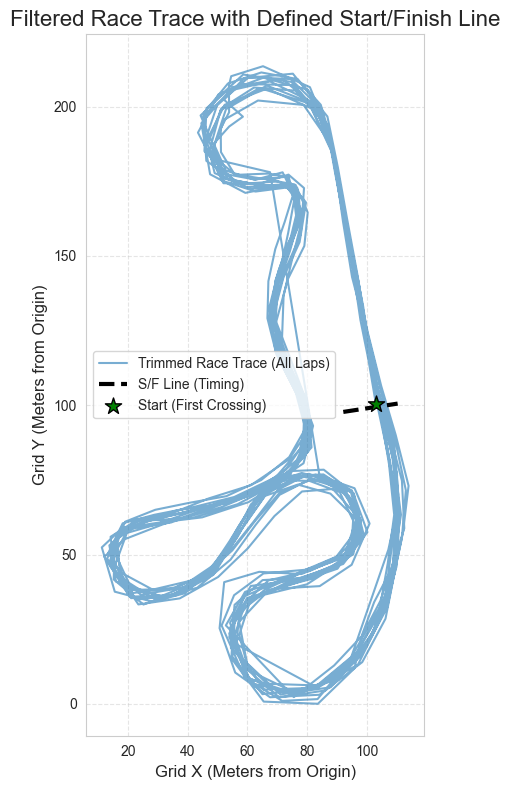

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ASSUME: lap_data_trimmed DataFrame exists from the previous filtering step.
# ASSUME: sf_p1_x, sf_p1_y, sf_p2_x, sf_p2_y exist for the S/F line coordinates.

def plot_trimmed_trace(df, sf_p1_x, sf_p1_y, sf_p2_x, sf_p2_y):
    """
    Plots the filtered race trace and marks the defined Start/Finish line.
    """
    if df.empty:
        print("❌ The trimmed DataFrame is empty. Check your S/F line crossing logic.")
        return

    sns.set_style("whitegrid")
    
    plt.figure(figsize=(10, 8))
    
    # 1. Plot the trimmed race trace (all laps)
    plt.plot(
        df['grid_x'], 
        df['grid_y'], 
        label='Trimmed Race Trace (All Laps)', 
        color='#1f77b4', 
        linewidth=1.5, # Slightly thinner line to show individual laps better
        alpha=0.6
    )
    
    # 2. Plot the Start/Finish Line
    plt.plot(
        [sf_p1_x, sf_p2_x],  # X coordinates
        [sf_p1_y, sf_p2_y],  # Y coordinates
        color='black', 
        linestyle='--', 
        linewidth=3, 
        label='S/F Line (Timing)'
    )
    
    # 3. Mark the true Start of the first full lap
    # This should be the first point in the trimmed DataFrame
    plt.scatter(
        df['grid_x'].iloc[0], 
        df['grid_y'].iloc[0], 
        color='green', 
        s=150, 
        marker='*', 
        edgecolor='black',
        zorder=5,
        label='Start (First Crossing)'
    )
    
    # 4. Set plot aesthetics
    plt.title('Filtered Race Trace with Defined Start/Finish Line', fontsize=16)
    plt.xlabel('Grid X (Meters from Origin)', fontsize=12)
    plt.ylabel('Grid Y (Meters from Origin)', fontsize=12)
    
    # Ensure axes are equally scaled
    plt.gca().set_aspect('equal', adjustable='box')
    
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Execute the visualization
plot_trimmed_trace(lap_data_trimmed, sf_p1_x, sf_p1_y, sf_p2_x, sf_p2_y)

In [13]:
import pandas as pd
import os # For checking file existence

# Assuming 'lap_dataframes' is the list of DataFrames created in Step 4.

# --- Configuration for Output ---
OUTPUT_CSV_FILE = "all_laps_cleaned_data.csv"
# ------------------------------

if lap_dataframes:
    print("\nStarting Step: Consolidate and Save CSV...")
    
    # 1. Add a Lap Number column to each DataFrame
    for i, df in enumerate(lap_dataframes):
        df['lap_number'] = i + 1
        
    # 2. Concatenate all individual lap DataFrames into one master DataFrame
    all_laps_df = pd.concat(lap_dataframes, ignore_index=True)
    
    # 3. Select and order the most useful columns for external analysis
    # We include grid_x/y, time, lap_number, and the calculated lap time
    final_cols = [
        'lap_number', 
        'seconds_elapsed', 
        'grid_x', 
        'grid_y', 
        'latitude', 
        'longitude', 
        'lap_time' 
    ]
    
    # Filter the DataFrame to only include the final columns
    all_laps_df = all_laps_df[final_cols]

    # 4. Save the combined DataFrame to CSV
    try:
        all_laps_df.to_csv(OUTPUT_CSV_FILE, index=False)
        print(f"✅ Success! All {len(lap_dataframes)} laps saved to '{OUTPUT_CSV_FILE}'")
        print(f"   Total rows saved: {len(all_laps_df)}")
    except Exception as e:
        print(f"❌ Error saving CSV: {e}")
        
else:
    print("\n⚠️ Cannot create CSV: The 'lap_dataframes' list is empty (check segmentation in Step 4).")


Starting Step: Consolidate and Save CSV...
✅ Success! All 14 laps saved to 'all_laps_cleaned_data.csv'
   Total rows saved: 652


Step 1: Data Loading and Initial Cleaning...
   -> Cleaned points: 904.

Step 2: Transforming GPS to Local Grid (UTM)...

Step 3: Aggressive Filtering Complete.
   -> Removed 5 points by Targeted Spatial filter (Top 5 segments).
   -> Removed 170 points by Time/Speed/Accel filter.

Step 4: Lap Segmentation and Trimming...
   -> Found 15 S/F crossings.
   -> Trimmed trace contains 652 points.
   -> Successfully segmented 14 individual laps.

Step 5: Visualizing the Final Composite Trace...


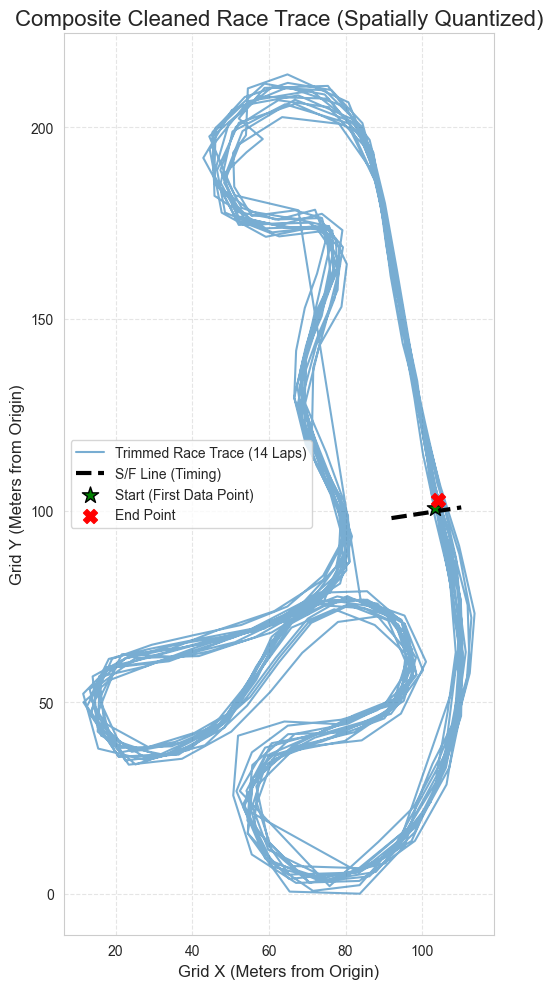


Step 6: Visualizing Individual Lap Traces...


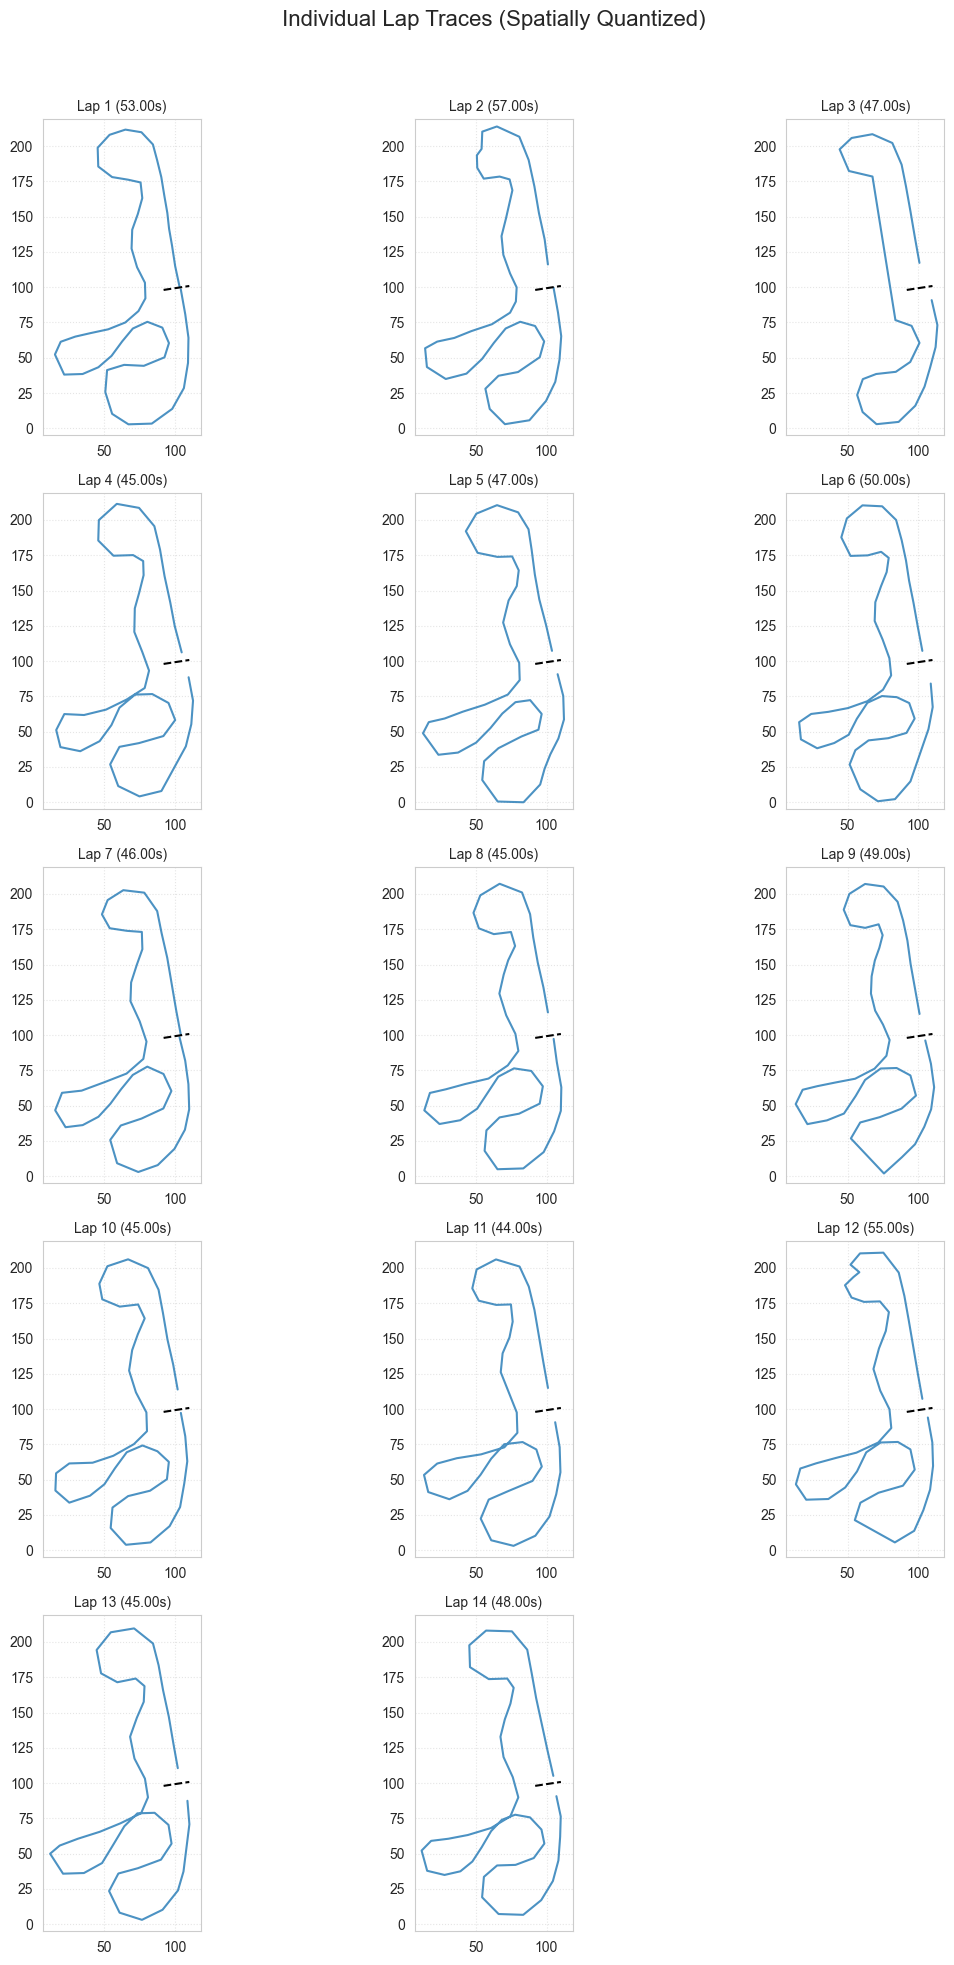

In [14]:
import sqlite3
import pandas as pd
import numpy as np
import utm
import matplotlib.pyplot as plt
import seaborn as sns
from geopy.distance import geodesic 

# --- CONFIGURATION (KART-SPECIFIC) ---
DATABASE_FILE = "700_IL-203_S-2025-10-16_22-04-11.sqlite"
TABLE_NAME = "Location"

# Start/Finish Line GPS (used for lap cutting)
SF_GPS_P1 = (38.64886, -90.13461)
SF_GPS_P2 = (38.64888, -90.13440)

# Cleaning Thresholds (ACCURATE KART LIMITS)
MAX_HORIZONTAL_ACCURACY = 10.0   # Tighter accuracy filter (in meters)
MAX_PHYSICAL_SPEED_MPS = 25.0    # Max kart speed (~56 mph)
MIN_SPEED_MPS = 2.5              # Min speed to filter out stationary/spin noise (m/s)
MAX_ACCEL_MPSS = 20.0            # Max acceleration filter (~2 Gs)
MAX_TIME_GAP_S = 2.0             # CRITICAL: Max time gap before a point is discarded (in seconds)
# ------------------------------------------

# Global variables for UTM origin shift
min_easting = None
min_northing = None
lap_dataframes = [] # List to store individual lap DataFrames

# --- 1. DATA LOADING AND INITIAL CLEANING ---
try:
    print("Step 1: Data Loading and Initial Cleaning...")
    conn = sqlite3.connect(DATABASE_FILE)
    location_df = pd.read_sql_query(f"SELECT * FROM {TABLE_NAME}", conn)
    conn.close()

    location_df_clean = location_df.replace(-1.0, np.nan).copy()

    required_cols = ['latitude', 'longitude', 'horizontalAccuracy', 'seconds_elapsed']
    location_df_clean.dropna(subset=required_cols, inplace=True)

    # Filter by required GPS accuracy
    location_df_clean = location_df_clean[
        location_df_clean['horizontalAccuracy'] <= MAX_HORIZONTAL_ACCURACY
    ].copy()
    
    # NEW: SPATIAL QUANTIZATION (Rounding Lat/Lon to 5 decimal places (~1.1m precision))
    location_df_clean['latitude'] = location_df_clean['latitude'].round(5)
    location_df_clean['longitude'] = location_df_clean['longitude'].round(5)
    
    location_df_clean.reset_index(drop=True, inplace=True)
    print(f"   -> Cleaned points: {len(location_df_clean)}.")

except Exception as e:
    print(f"❌ ERROR in Step 1 (Loading/Cleaning): {e}")
    exit()

# --- 2. GPS TO LOCAL GRID TRANSFORMATION (UTM) ---

def to_utm(row):
    easting, northing, _, _ = utm.from_latlon(row['latitude'], row['longitude'])
    return pd.Series({'easting': easting, 'northing': northing})

print("\nStep 2: Transforming GPS to Local Grid (UTM)...")
location_df_clean[['easting', 'northing']] = location_df_clean.apply(to_utm, axis=1)

min_easting = location_df_clean['easting'].min()
min_northing = location_df_clean['northing'].min()

# Create the final grid coordinates with the origin at the bottom-left
location_df_clean['grid_x'] = location_df_clean['easting'] - min_easting
location_df_clean['grid_y'] = location_df_clean['northing'] - min_northing


# --- 3. TARGETED SPATIAL FILTERING (Final Fix) ---

def filter_teleportation_jumps_final(df):
    """
    Applies targeted spatial filter (removes top N longest segments) 
    followed by time/speed filters.
    """
    df_temp = df.copy()
    
    # CRITICAL: Drop rows with NaN to ensure movement metrics are correct
    critical_cols = ['easting', 'northing', 'seconds_elapsed']
    df_temp.dropna(subset=critical_cols, inplace=True)
    df_temp.reset_index(drop=True, inplace=True)
    
    # 1. TARGETED SPATIAL REMOVAL (Remove the top 5 longest segments)
    
    # Calculate segment distance
    df_temp['prev_grid_x'] = df_temp['grid_x'].shift(1)
    df_temp['prev_grid_y'] = df_temp['grid_y'].shift(1)
    
    df_temp['segment_distance'] = np.sqrt(
        (df_temp['grid_x'] - df_temp['prev_grid_x'])**2 + 
        (df_temp['grid_y'] - df_temp['prev_grid_y'])**2
    )
    
    # Set the number of longest segments to remove (guarantees the jump is hit)
    N_TO_REMOVE = 5
    
    # Get the indices corresponding to the N largest distances
    largest_segments = df_temp.nlargest(N_TO_REMOVE, 'segment_distance')
    indices_to_drop = largest_segments.index.tolist()
    
    df_filtered = df_temp.drop(indices_to_drop).copy()
    removed_count_spatial = len(indices_to_drop)
    
    # 2. TIME & MOVEMENT FILTER (Standard physical limits on the spatially-cleaned data)

    # Clean up temporary columns before the next stage of calculation
    df_filtered.drop(columns=['prev_grid_x', 'prev_grid_y', 'segment_distance'], errors='ignore', inplace=True)
    df_filtered.reset_index(drop=True, inplace=True)
    
    # Recalculate movement metrics on the newly cleaned sequence
    df_filtered['prev_time'] = df_filtered['seconds_elapsed'].shift(1)
    df_filtered['delta_t'] = df_filtered['seconds_elapsed'] - df_filtered['prev_time']
    
    df_filtered['segment_distance'] = np.sqrt(
        (df_filtered['grid_x'] - df_filtered['grid_x'].shift(1))**2 + 
        (df_filtered['grid_y'] - df_filtered['grid_y'].shift(1))**2
    )

    df_filtered['speed_calc'] = df_filtered['segment_distance'] / df_filtered['delta_t'].replace(0, np.nan) 
    df_filtered['prev_speed'] = df_filtered['speed_calc'].shift(1)
    df_filtered['delta_v'] = df_filtered['speed_calc'] - df_filtered['prev_speed']
    df_filtered['accel_calc'] = df_filtered['delta_v'] / df_filtered['delta_t'].shift(1).replace(0, np.nan)
    
    # FILTER LOGIC
    is_valid_time_gap = (df_filtered['delta_t'] <= MAX_TIME_GAP_S)
    is_valid_speed = (df_filtered['speed_calc'] < MAX_PHYSICAL_SPEED_MPS) & \
                     (df_filtered['speed_calc'] > MIN_SPEED_MPS)
    is_valid_accel = (df_filtered['accel_calc'].abs() < MAX_ACCEL_MPSS) | df_filtered['accel_calc'].isna()
    
    is_valid_point = (is_valid_speed & is_valid_accel & is_valid_time_gap) | (df_filtered.index < 2)
    
    df_final = df_filtered[is_valid_point].copy()
    
    removed_count_final = len(df_filtered) - len(df_final)
    
    # Clean up and return
    cols_to_drop = [col for col in df_final.columns if col not in df.columns]
    df_final.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    df_final.reset_index(drop=True, inplace=True)
    
    print(f"\nStep 3: Aggressive Filtering Complete.")
    print(f"   -> Removed {removed_count_spatial} points by Targeted Spatial filter (Top {N_TO_REMOVE} segments).")
    print(f"   -> Removed {removed_count_final} points by Time/Speed/Accel filter.")
    return df_final

location_df_clean = filter_teleportation_jumps_final(location_df_clean)


# --- 4. LAP SEGMENTATION SETUP (Defining and Trimming to S/F Line) ---

# Convert S/F GPS points to Grid_X/Grid_Y
sf_grid_coords = []
for lat, lon in [SF_GPS_P1, SF_GPS_P2]:
    easting, northing, _, _ = utm.from_latlon(lat, lon)
    grid_x = easting - min_easting
    grid_y = northing - min_northing
    sf_grid_coords.append((grid_x, grid_y))

sf_p1_x, sf_p1_y = sf_grid_coords[0]
sf_p2_x, sf_p2_y = sf_grid_coords[1]
sf_p1 = (sf_p1_x, sf_p1_y)
sf_p2 = (sf_p2_x, sf_p2_y)

print("\nStep 4: Lap Segmentation and Trimming...")

# Function to check for line segment crossing
def check_crossing(p_prev, p_curr, sf_p1, sf_p2):
    def orientation(p, q, r):
        val = (q[1] - p[1]) * (r[0] - q[0]) - (q[0] - p[0]) * (r[1] - q[1])
        if val == 0: return 0
        return 1 if val > 0 else 2

    o1 = orientation(sf_p1, sf_p2, p_prev)
    o2 = orientation(sf_p1, sf_p2, p_curr)
    o3 = orientation(p_prev, p_curr, sf_p1)
    o4 = orientation(p_prev, p_curr, sf_p2)

    return o1 != 0 and o2 != 0 and o3 != 0 and o4 != 0 and o1 != o2 and o3 != o4

# Find all crossing points in the cleaned trace
crossing_indices = []
for i in range(1, len(location_df_clean)):
    p_prev = (location_df_clean.iloc[i-1]['grid_x'], location_df_clean.iloc[i-1]['grid_y'])
    p_curr = (location_df_clean.iloc[i]['grid_x'], location_df_clean.iloc[i]['grid_y'])
    
    if check_crossing(p_prev, p_curr, sf_p1, sf_p2):
        crossing_indices.append(i)

# Trim data to the first and last complete crossing
if len(crossing_indices) < 2:
    print("   -> WARNING: Less than two crossings found. Cannot segment laps.")
    lap_data_trimmed = location_df_clean.copy() 
else:
    first_index = crossing_indices[0] 
    last_index = crossing_indices[-1]

    lap_data_trimmed = location_df_clean.iloc[first_index : last_index + 1].copy()
    lap_data_trimmed.reset_index(drop=True, inplace=True)
    print(f"   -> Found {len(crossing_indices)} S/F crossings.")
    print(f"   -> Trimmed trace contains {len(lap_data_trimmed)} points.")

    # Create list of individual lap DataFrames
    original_start_index = location_df_clean.index[first_index]
    trimmed_crossing_indices = [idx - original_start_index for idx in crossing_indices]
    
    lap_dataframes = []
    for i in range(len(trimmed_crossing_indices) - 1):
        start_idx = trimmed_crossing_indices[i]
        end_idx = trimmed_crossing_indices[i+1] # The next crossing is the end of the lap
        
        lap_df = lap_data_trimmed.iloc[start_idx:end_idx].copy()
        
        # Calculate the lap time for convenience
        lap_time = lap_df['seconds_elapsed'].iloc[-1] - lap_df['seconds_elapsed'].iloc[0]
        lap_df['lap_time'] = lap_time
        lap_df['lap_number'] = i + 1
        
        lap_dataframes.append(lap_df)
    
    print(f"   -> Successfully segmented {len(lap_dataframes)} individual laps.")

# --- 5. VISUALIZATION OF THE COMPOSITE TRACE ---

def plot_composite_trace(df, sf_x1, sf_y1, sf_x2, sf_y2):
    """Plots the filtered and trimmed race trace with the S/F line marked."""
    sns.set_style("whitegrid")
    
    plt.figure(figsize=(8, 10))
    
    num_laps = len(lap_dataframes) if lap_dataframes else 0
    plt.plot(
        df['grid_x'], 
        df['grid_y'], 
        label=f'Trimmed Race Trace ({num_laps} Laps)', 
        color='#1f77b4', 
        linewidth=1.5, 
        alpha=0.6
    )
    
    # Plot the Start/Finish Line
    plt.plot([sf_x1, sf_x2], [sf_y1, sf_y2], color='black', linestyle='--', linewidth=3, label='S/F Line (Timing)')
    plt.scatter(df['grid_x'].iloc[0], df['grid_y'].iloc[0], color='green', s=150, marker='*', edgecolor='black', zorder=5, label='Start (First Data Point)')
    plt.scatter(df['grid_x'].iloc[-1], df['grid_y'].iloc[-1], color='red', s=100, marker='X', zorder=5, label='End Point')
    
    plt.title('Composite Cleaned Race Trace (Spatially Quantized)', fontsize=16)
    plt.xlabel('Grid X (Meters from Origin)', fontsize=12)
    plt.ylabel('Grid Y (Meters from Origin)', fontsize=12)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

print("\nStep 5: Visualizing the Final Composite Trace...")
plot_composite_trace(lap_data_trimmed, sf_p1_x, sf_p1_y, sf_p2_x, sf_p2_y)


# --- 6. VISUALIZATION OF INDIVIDUAL LAP TRACES ---

def plot_individual_laps(lap_dfs, sf_x1, sf_y1, sf_x2, sf_y2):
    """Plots each lap on its own subplot for detailed inspection."""
    if not lap_dfs:
        print("❌ No individual laps to plot.")
        return

    num_laps = len(lap_dfs)
    cols = 3
    rows = int(np.ceil(num_laps / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten() 
    
    # Calculate uniform axis limits for easy comparison
    all_x = np.concatenate([df['grid_x'].values for df in lap_dfs])
    all_y = np.concatenate([df['grid_y'].values for df in lap_dfs])
    max_x, min_x = all_x.max(), all_x.min()
    max_y, min_y = all_y.max(), all_y.min()
    
    for i, df in enumerate(lap_dfs):
        ax = axes[i]
        
        # Plot the trace
        ax.plot(df['grid_x'], df['grid_y'], color='#1f77b4', linewidth=1.5, alpha=0.8)
        
        # Plot the Start/Finish Line
        ax.plot([sf_x1, sf_x2], [sf_y1, sf_y2], color='black', linestyle='--', linewidth=1.5)
        
        # Set uniform axes limits 
        ax.set_xlim(min_x - 5, max_x + 5)
        ax.set_ylim(min_y - 5, max_y + 5)
        
        ax.set_aspect('equal', adjustable='box')
        
        lap_time_s = df['lap_time'].iloc[0]
        ax.set_title(f"Lap {i+1} ({lap_time_s:.2f}s)", fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.5)

    # Hide any unused subplots
    for j in range(num_laps, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle('Individual Lap Traces (Spatially Quantized)', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

print("\nStep 6: Visualizing Individual Lap Traces...")
plot_individual_laps(lap_dataframes, sf_p1_x, sf_p1_y, sf_p2_x, sf_p2_y)

In [15]:
import sqlite3
import pandas as pd
import numpy as np
import utm
import matplotlib.pyplot as plt
import seaborn as sns
from geopy.distance import geodesic 

# --- CONFIGURATION (KART-SPECIFIC) ---
DATABASE_FILE = "700_IL-203_S-2025-10-16_22-04-11.sqlite"
TABLE_NAME = "Location"

# Start/Finish Line GPS (used for lap cutting)
SF_GPS_P1 = (38.64886, -90.13461)
SF_GPS_P2 = (38.64888, -90.13440)

# Cleaning Thresholds (ACCURATE KART LIMITS)
MAX_HORIZONTAL_ACCURACY = 10.0   # Tighter accuracy filter (in meters)
MAX_PHYSICAL_SPEED_MPS = 25.0    # Max kart speed (~56 mph)
MIN_SPEED_MPS = 2.5              # Min speed to filter out stationary/spin noise (m/s)
MAX_ACCEL_MPSS = 20.0            # Max acceleration filter (~2 Gs)
MAX_TIME_GAP_S = 2.0             # CRITICAL: Max time gap before a point is discarded (in seconds)

# NEW: Smoothing Factor (Alpha) for Exponential Moving Average (EMA)
# Smaller alpha = smoother trace (more historical data considered)
SMOOTHING_ALPHA = 0.25 # Typical values range from 0.05 (very smooth) to 0.5 (light smoothing)
# ------------------------------------------

# Global variables for UTM origin shift
min_easting = None
min_northing = None
lap_dataframes = [] 

# --- 1. DATA LOADING AND INITIAL CLEANING ---
try:
    print("Step 1: Data Loading and Initial Cleaning...")
    conn = sqlite3.connect(DATABASE_FILE)
    location_df = pd.read_sql_query(f"SELECT * FROM {TABLE_NAME}", conn)
    conn.close()

    location_df_clean = location_df.replace(-1.0, np.nan).copy()
    required_cols = ['latitude', 'longitude', 'horizontalAccuracy', 'seconds_elapsed']
    location_df_clean.dropna(subset=required_cols, inplace=True)
    location_df_clean = location_df_clean[
        location_df_clean['horizontalAccuracy'] <= MAX_HORIZONTAL_ACCURACY
    ].copy()
    
    # SPATIAL QUANTIZATION (Rounding Lat/Lon to 5 decimal places (~1.1m precision))
    location_df_clean['latitude'] = location_df_clean['latitude'].round(5)
    location_df_clean['longitude'] = location_df_clean['longitude'].round(5)
    
    location_df_clean.reset_index(drop=True, inplace=True)
    print(f"   -> Cleaned points: {len(location_df_clean)}.")

except Exception as e:
    print(f"❌ ERROR in Step 1 (Loading/Cleaning): {e}")
    exit()

# --- 2. GPS TO LOCAL GRID TRANSFORMATION (UTM) ---

def to_utm(row):
    easting, northing, _, _ = utm.from_latlon(row['latitude'], row['longitude'])
    return pd.Series({'easting': easting, 'northing': northing})

print("\nStep 2: Transforming GPS to Local Grid (UTM)...")
location_df_clean[['easting', 'northing']] = location_df_clean.apply(to_utm, axis=1)
min_easting = location_df_clean['easting'].min()
min_northing = location_df_clean['northing'].min()
location_df_clean['grid_x'] = location_df_clean['easting'] - min_easting
location_df_clean['grid_y'] = location_df_clean['northing'] - min_northing


# --- 3. TARGETED SPATIAL FILTERING (Final Fix) ---

def filter_teleportation_jumps_final(df):
    """
    Applies targeted spatial filter (removes top N longest segments) 
    followed by time/speed filters.
    """
    df_temp = df.copy()
    critical_cols = ['easting', 'northing', 'seconds_elapsed']
    df_temp.dropna(subset=critical_cols, inplace=True)
    df_temp.reset_index(drop=True, inplace=True)
    
    # 1. TARGETED SPATIAL REMOVAL (Remove the top 5 longest segments)
    df_temp['prev_grid_x'] = df_temp['grid_x'].shift(1)
    df_temp['prev_grid_y'] = df_temp['grid_y'].shift(1)
    df_temp['segment_distance'] = np.sqrt(
        (df_temp['grid_x'] - df_temp['prev_grid_x'])**2 + 
        (df_temp['grid_y'] - df_temp['prev_grid_y'])**2
    )
    
    N_TO_REMOVE = 5
    largest_segments = df_temp.nlargest(N_TO_REMOVE, 'segment_distance')
    indices_to_drop = largest_segments.index.tolist()
    
    df_filtered = df_temp.drop(indices_to_drop).copy()
    removed_count_spatial = len(indices_to_drop)
    
    # 2. TIME & MOVEMENT FILTER (Standard physical limits on the spatially-cleaned data)
    df_filtered.drop(columns=['prev_grid_x', 'prev_grid_y', 'segment_distance'], errors='ignore', inplace=True)
    df_filtered.reset_index(drop=True, inplace=True)
    
    df_filtered['prev_time'] = df_filtered['seconds_elapsed'].shift(1)
    df_filtered['delta_t'] = df_filtered['seconds_elapsed'] - df_filtered['prev_time']
    
    df_filtered['segment_distance'] = np.sqrt(
        (df_filtered['grid_x'] - df_filtered['grid_x'].shift(1))**2 + 
        (df_filtered['grid_y'] - df_filtered['grid_y'].shift(1))**2
    )

    df_filtered['speed_calc'] = df_filtered['segment_distance'] / df_filtered['delta_t'].replace(0, np.nan) 
    df_filtered['prev_speed'] = df_filtered['speed_calc'].shift(1)
    df_filtered['delta_v'] = df_filtered['speed_calc'] - df_filtered['prev_speed']
    df_filtered['accel_calc'] = df_filtered['delta_v'] / df_filtered['delta_t'].shift(1).replace(0, np.nan)
    
    # FILTER LOGIC
    is_valid_time_gap = (df_filtered['delta_t'] <= MAX_TIME_GAP_S)
    is_valid_speed = (df_filtered['speed_calc'] < MAX_PHYSICAL_SPEED_MPS) & \
                     (df_filtered['speed_calc'] > MIN_SPEED_MPS)
    is_valid_accel = (df_filtered['accel_calc'].abs() < MAX_ACCEL_MPSS) | df_filtered['accel_calc'].isna()
    
    is_valid_point = (is_valid_speed & is_valid_accel & is_valid_time_gap) | (df_filtered.index < 2)
    
    df_final = df_filtered[is_valid_point].copy()
    
    removed_count_final = len(df_filtered) - len(df_final)
    
    cols_to_drop = [col for col in df_final.columns if col not in df.columns]
    df_final.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    df_final.reset_index(drop=True, inplace=True)
    
    print(f"\nStep 3: Aggressive Filtering Complete.")
    print(f"   -> Removed {removed_count_spatial} points by Targeted Spatial filter (Top {N_TO_REMOVE} segments).")
    print(f"   -> Removed {removed_count_final} points by Time/Speed/Accel filter.")
    return df_final

location_df_clean = filter_teleportation_jumps_final(location_df_clean)


# --- NEW FUNCTION: EXPONENTIAL SMOOTHING (FUSION) ---

def apply_ema_smoothing(df, alpha):
    """Applies Exponential Moving Average (EMA) smoothing to the grid coordinates."""
    
    # Check if the columns exist before attempting to access them
    if 'grid_x' not in df.columns or 'grid_y' not in df.columns:
        print("Error: grid_x or grid_y columns missing for smoothing.")
        return df

    df['grid_x_smooth'] = df['grid_x'].ewm(alpha=alpha, adjust=False).mean()
    df['grid_y_smooth'] = df['grid_y'].ewm(alpha=alpha, adjust=False).mean()
    
    return df

# --- 4. LAP SEGMENTATION, TRIMMING, AND SMOOTHING ---

# Convert S/F GPS points to Grid_X/Grid_Y
sf_grid_coords = []
for lat, lon in [SF_GPS_P1, SF_GPS_P2]:
    easting, northing, _, _ = utm.from_latlon(lat, lon)
    grid_x = easting - min_easting
    grid_y = northing - min_northing
    sf_grid_coords.append((grid_x, grid_y))

sf_p1_x, sf_p1_y = sf_grid_coords[0]
sf_p2_x, sf_p2_y = sf_grid_coords[1]
sf_p1 = (sf_p1_x, sf_p1_y)
sf_p2 = (sf_p2_x, sf_p2_y)

print("\nStep 4: Lap Segmentation, Trimming, and Smoothing...")

def check_crossing(p_prev, p_curr, sf_p1, sf_p2):
    def orientation(p, q, r):
        val = (q[1] - p[1]) * (r[0] - q[0]) - (q[0] - p[0]) * (r[1] - q[1])
        if val == 0: return 0
        return 1 if val > 0 else 2

    o1 = orientation(sf_p1, sf_p2, p_prev)
    o2 = orientation(sf_p1, sf_p2, p_curr)
    o3 = orientation(p_prev, p_curr, sf_p1)
    o4 = orientation(p_prev, p_curr, sf_p2)

    return o1 != 0 and o2 != 0 and o3 != 0 and o4 != 0 and o1 != o2 and o3 != o4

crossing_indices = []
for i in range(1, len(location_df_clean)):
    p_prev = (location_df_clean.iloc[i-1]['grid_x'], location_df_clean.iloc[i-1]['grid_y'])
    p_curr = (location_df_clean.iloc[i]['grid_x'], location_df_clean.iloc[i]['grid_y'])
    if check_crossing(p_prev, p_curr, sf_p1, sf_p2):
        crossing_indices.append(i)

if len(crossing_indices) < 2:
    print("   -> WARNING: Less than two crossings found. Cannot segment laps.")
    lap_data_trimmed = location_df_clean.copy() 
else:
    first_index = crossing_indices[0] 
    last_index = crossing_indices[-1]

    lap_data_trimmed = location_df_clean.iloc[first_index : last_index + 1].copy()
    lap_data_trimmed.reset_index(drop=True, inplace=True)

    # 4a. Apply smoothing to the trimmed composite trace
    lap_data_trimmed = apply_ema_smoothing(lap_data_trimmed, SMOOTHING_ALPHA)
    
    # 4b. Segment and smooth individual laps
    original_start_index = location_df_clean.index[first_index]
    trimmed_crossing_indices = [idx - original_start_index for idx in crossing_indices]
    
    lap_dataframes = []
    for i in range(len(trimmed_crossing_indices) - 1):
        start_idx = trimmed_crossing_indices[i]
        end_idx = trimmed_crossing_indices[i+1]
        
        lap_df = lap_data_trimmed.iloc[start_idx:end_idx].copy()
        lap_time = lap_df['seconds_elapsed'].iloc[-1] - lap_df['seconds_elapsed'].iloc[0]
        lap_df['lap_time'] = lap_time
        lap_df['lap_number'] = i + 1
        
        # NOTE: Smoothing is already applied to the segment above, so we just append.
        lap_dataframes.append(lap_df)
    
    print(f"   -> Successfully segmented and smoothed {len(lap_dataframes)} individual laps.")

# --- 5. VISUALIZATION OF THE COMPOSITE SMOOTHED TRACE ---

def plot_composite_trace_smoothed(df, sf_x1, sf_y1, sf_x2, sf_y2):
    """Plots the filtered and TRIMMED *smoothed* trace."""
    sns.set_style("whitegrid")
    
    plt.figure(figsize=(8, 10))
    num_laps = len(lap_dataframes) if lap_dataframes else 0
    
    # Plotting the SMOOTHED coordinates
    plt.plot(
        df['grid_x_smooth'], 
        df['grid_y_smooth'], 
        label=f'Smoothed Trace ({num_laps} Laps)', 
        color='#1f77b4', 
        linewidth=1.5, 
        alpha=0.8
    )
    
    # Plot Start/Finish Line and markers using SMOOTHED coordinates for start/end
    plt.plot([sf_x1, sf_x2], [sf_y1, sf_y2], color='black', linestyle='--', linewidth=3, label='S/F Line (Timing)')
    plt.scatter(df['grid_x_smooth'].iloc[0], df['grid_y_smooth'].iloc[0], color='green', s=150, marker='*', edgecolor='black', zorder=5, label='Start (First Data Point)')
    plt.scatter(df['grid_x_smooth'].iloc[-1], df['grid_y_smooth'].iloc[-1], color='red', s=100, marker='X', zorder=5, label='End Point')
    
    plt.title('Composite Cleaned Race Trace (EMA Smoothed)', fontsize=16)
    plt.xlabel('Grid X (Meters from Origin)', fontsize=12)
    plt.ylabel('Grid Y (Meters from Origin)', fontsize=12)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    # Save the figure to a file
    plt.savefig('composite_smoothed_trace.png')
    plt.close()

print("\nStep 5: Visualizing the Composite Smoothed Trace...")
plot_composite_trace_smoothed(lap_data_trimmed, sf_p1_x, sf_p1_y, sf_p2_x, sf_p2_y)

# --- 6. VISUALIZATION OF INDIVIDUAL SMOOTHED LAP TRACES ---

def plot_individual_laps_smoothed(lap_dfs, sf_x1, sf_y1, sf_x2, sf_y2):
    """Plots each lap on its own subplot using SMOOTHED coordinates."""
    if not lap_dfs:
        print("❌ No individual laps to plot.")
        return

    num_laps = len(lap_dfs)
    cols = 3
    rows = int(np.ceil(num_laps / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten() 
    
    # Calculate uniform axis limits for easy comparison
    all_x = np.concatenate([df['grid_x_smooth'].values for df in lap_dfs])
    all_y = np.concatenate([df['grid_y_smooth'].values for df in lap_dfs])
    max_x, min_x = all_x.max(), all_x.min()
    max_y, min_y = all_y.max(), all_y.min()
    
    for i, df in enumerate(lap_dfs):
        ax = axes[i]
        
        # Plotting the SMOOTHED coordinates
        ax.plot(df['grid_x_smooth'], df['grid_y_smooth'], color='#1f77b4', linewidth=1.5, alpha=0.8)
        
        # Plot the Start/Finish Line
        ax.plot([sf_x1, sf_x2], [sf_y1, sf_y2], color='black', linestyle='--', linewidth=1.5)
        
        # Set uniform axes limits 
        ax.set_xlim(min_x - 5, max_x + 5)
        ax.set_ylim(min_y - 5, max_y + 5)
        
        ax.set_aspect('equal', adjustable='box')
        
        lap_time_s = df['lap_time'].iloc[0]
        ax.set_title(f"Lap {i+1} ({lap_time_s:.2f}s) SM", fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.5)

    # Hide any unused subplots
    for j in range(num_laps, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle('Individual Lap Traces (EMA Smoothed - Fusion)', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Save the figure to a file
    plt.savefig('individual_smoothed_laps.png')
    plt.close()

print("\nStep 6: Visualizing Individual Smoothed Lap Traces...")
plot_individual_laps_smoothed(lap_dataframes, sf_p1_x, sf_p1_y, sf_p2_x, sf_p2_y)

# --- 7. Final CSV Output (Optional, but highly recommended) ---
if lap_dataframes:
    all_laps_df = pd.concat(lap_dataframes, ignore_index=True)
    
    # Use the smoothed coordinates for the final output
    final_cols = [
        'lap_number', 
        'seconds_elapsed', 
        'grid_x_smooth',  # SMOOTHED X
        'grid_y_smooth',  # SMOOTHED Y
        'lap_time' 
    ]
    
    all_laps_df[final_cols].to_csv('all_laps_smoothed_data.csv', index=False)
    print(f"\nFinal data saved to: 'all_laps_smoothed_data.csv'")

Step 1: Data Loading and Initial Cleaning...
   -> Cleaned points: 904.

Step 2: Transforming GPS to Local Grid (UTM)...

Step 3: Aggressive Filtering Complete.
   -> Removed 5 points by Targeted Spatial filter (Top 5 segments).
   -> Removed 170 points by Time/Speed/Accel filter.

Step 4: Lap Segmentation, Trimming, and Smoothing...
   -> Successfully segmented and smoothed 14 individual laps.

Step 5: Visualizing the Composite Smoothed Trace...

Step 6: Visualizing Individual Smoothed Lap Traces...

Final data saved to: 'all_laps_smoothed_data.csv'


In [16]:
import sqlite3
import pandas as pd
import numpy as np
import utm
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
DATABASE_FILE = "700_IL-203_S-2025-10-16_22-04-11.sqlite"
TABLE_NAME = "Location"
OUTPUT_CSV_FILE = "location_raw_data_with_coordinates.csv"
PLOT_FILE = "location_raw_trace.png"
# ---------------------

def analyze_and_plot_raw_data(db_file, table_name, csv_file, plot_file):
    try:
        # 1. Load Data
        conn = sqlite3.connect(db_file)
        df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
        conn.close()

        # 2. Basic Cleaning and Preparation
        # Replace common placeholder -1.0 with NaN and drop rows missing Lat/Lon
        df = df.replace(-1.0, np.nan)
        df.dropna(subset=['latitude', 'longitude'], inplace=True)
        df.reset_index(drop=True, inplace=True)
        
        if df.empty:
            print("❌ Error: DataFrame is empty after basic cleaning.")
            return

        # 3. Coordinate Transformation (Lat/Lon -> UTM Grid X/Y)
        # Convert GPS to a flat Cartesian system (meters) for accurate plotting
        def to_utm(row):
            easting, northing, _, _ = utm.from_latlon(row['latitude'], row['longitude'])
            return pd.Series({'easting': easting, 'northing': northing})

        df[['easting', 'northing']] = df.apply(to_utm, axis=1)

        # Create a local grid by setting the minimum point as (0, 0)
        min_easting = df['easting'].min()
        min_northing = df['northing'].min()
        df['grid_x'] = df['easting'] - min_easting
        df['grid_y'] = df['northing'] - min_northing

        # 4. Plot the Raw Trace
        plt.figure(figsize=(8, 10))
        plt.plot(df['grid_x'], df['grid_y'], color='#1f77b4', linewidth=1.0, alpha=0.7)
        
        # Mark Start (first point)
        plt.scatter(df['grid_x'].iloc[0], df['grid_y'].iloc[0], color='green', s=50, marker='o', label='Start')
        
        plt.title('Raw Race Trace (UTM Grid)', fontsize=14)
        plt.xlabel('Grid X (Meters)', fontsize=12)
        plt.ylabel('Grid Y (Meters)', fontsize=12)
        plt.gca().set_aspect('equal', adjustable='box')
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.legend()
        plt.savefig(plot_file)
        plt.close()

        # 5. Save to CSV
        df.to_csv(csv_file, index=False)

        print(f"✅ Success!")
        print(f"   Plot saved to: '{plot_file}'")
        print(f"   Raw data saved to: '{csv_file}'")
        print(f"   Total records processed: {len(df)}")

    except Exception as e:
        print(f"❌ An error occurred: {e}")

# Execute the function
analyze_and_plot_raw_data(DATABASE_FILE, TABLE_NAME, OUTPUT_CSV_FILE, PLOT_FILE)

✅ Success!
   Plot saved to: 'location_raw_trace.png'
   Raw data saved to: 'location_raw_data_with_coordinates.csv'
   Total records processed: 943


In [23]:
import sqlite3
import pandas as pd

# Database and table information
db_file = '700_IL-203_S-2025-10-16_22-04-11.sqlite'
table_name = 'location'
output_csv = 'modified_location_data.csv'

# Connect to the SQLite database
conn = sqlite3.connect(db_file)

# SQL to select data and apply modifications:
# 1. ROUND(Latitude, 5) and ROUND(Longitude, 5) clips to 5 decimal places.
# 2. 120.0 AS Altitude sets a constant altitude of 120m (assuming Altitude is the column name).
#    If the column is named differently, replace 'Altitude' in the SELECT statement.
select_query = f"""
SELECT 
    *, 
    ROUND(Latitude, 5) AS Latitude, 
    ROUND(Longitude, 5) AS Longitude, 
    120.0 AS Altitude
FROM 
    {table_name};
"""

# Read the data into a Pandas DataFrame, applying the SQL modifications
df = pd.read_sql_query(select_query, conn)

# Close the database connection
conn.close()

# Save the DataFrame to a CSV file
df.to_csv(output_csv, index=False)

print(f"Data from table '{table_name}' has been modified and saved to '{output_csv}'")

Data from table 'location' has been modified and saved to 'modified_location_data.csv'


In [24]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
DATABASE_FILE = "700_IL-203_S-2025-10-16_22-04-11.sqlite"
TABLE_NAME = "Location"
OUTPUT_CSV_FILE = "location_quantized_and_filtered.csv"
PLOT_FILE = "location_quantized_trace.png"
FIXED_ALTITUDE_METERS = 120.0
# ---------------------

def quantize_filter_and_plot_data(db_file, table_name, csv_file, plot_file, fixed_altitude):
    try:
        # 1. Load Data
        conn = sqlite3.connect(db_file)
        df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
        conn.close()

        # Initial cleaning: Replace -1.0 with NaN and ensure Lat/Lon exist
        df = df.replace(-1.0, np.nan)
        df.dropna(subset=['latitude', 'longitude'], inplace=True)
        
        # --- CRITICAL FILTERING AND ROUNDING ---
        
        # 2. Filter 1: Remove all records where speed is -1 (which were set to NaN above)
        # Note: We assume the original data has a 'speed' column where -1 indicates missing data.
        rows_before = len(df)
        df = df[df['speed'].notna()].copy()
        print(f"   -> Removed {rows_before - len(df)} rows where speed was -1.")
        
        # 3. Rounding (Quantization)
        df['seconds_elapsed'] = df['seconds_elapsed'].round(3)
        df['latitude'] = df['latitude'].round(5)
        df['longitude'] = df['longitude'].round(5)
        print("   -> Applied rounding to time (0.000) and GPS (5 decimal places).")
        
        # 4. Set Fixed Altitude
        df['altitude'] = fixed_altitude

        df.reset_index(drop=True, inplace=True)
        if df.empty:
            print("❌ Error: DataFrame is empty after filtering.")
            return

        # 5. Simple Geometric Conversion for Plotting
        # Latitude/Longitude is used directly for approximate plot positioning.
        
        min_lon = df['longitude'].min()
        min_lat = df['latitude'].min()
        SCALE_FACTOR = 111000 # Approx meters per degree latitude
        
        df['grid_x'] = (df['longitude'] - min_lon) * SCALE_FACTOR
        df['grid_y'] = (df['latitude'] - min_lat) * SCALE_FACTOR

        # 6. Plot the Quantized Trace
        plt.figure(figsize=(8, 10))
        plt.plot(df['grid_x'], df['grid_y'], color='#1f77b4', linewidth=1.0, alpha=0.7)
        
        plt.scatter(df['grid_x'].iloc[0], df['grid_y'].iloc[0], color='green', s=50, marker='o', label='Start')
        
        plt.title('Quantized Race Trace (Reduced Noise)', fontsize=14)
        plt.xlabel('Grid X (Approximate Meters)', fontsize=12)
        plt.ylabel('Grid Y (Approximate Meters)', fontsize=12)
        plt.gca().set_aspect('equal', adjustable='box')
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.legend()
        plt.savefig(plot_file)
        plt.close()

        # 7. Save to CSV
        df.to_csv(csv_file, index=False)

        print(f"\n✅ Processing Complete.")
        print(f"   Plot saved to: '{plot_file}'")
        print(f"   Final data saved to: '{csv_file}'")
        print(f"   Total valid records: {len(df)}")

    except Exception as e:
        print(f"❌ An unexpected error occurred: {e}")

# Execute the function
quantize_filter_and_plot_data(DATABASE_FILE, TABLE_NAME, OUTPUT_CSV_FILE, PLOT_FILE, FIXED_ALTITUDE_METERS)

   -> Removed 2 rows where speed was -1.
   -> Applied rounding to time (0.000) and GPS (5 decimal places).

✅ Processing Complete.
   Plot saved to: 'location_quantized_trace.png'
   Final data saved to: 'location_quantized_and_filtered.csv'
   Total valid records: 941


In [25]:
import pandas as pd
import numpy as np
import sqlite3
from filterpy.kalman import ExtendedKalmanFilter
from filterpy.common import Q_discrete_white_noise
from scipy.spatial.transform import Rotation as R
from geographiclib.geodesic import Geodesic

# --- CONFIGURATION ---
DATABASE_FILE = "700_IL-203_S-2025-10-16_22-04-11.sqlite"
OUTPUT_CSV_FILE = "fused_trace.csv"
FIXED_ALTITUDE_METERS = 120.0
g = 9.80665 # Standard gravity [m/s^2]

# WGS-84 ellipsoid constants for local coordinate conversion
geod = Geodesic.WGS84

# --- DATA PREPARATION FUNCTIONS ---

def read_data(db_file):
    """Reads Location, Accelerometer, Gyroscope, and Orientation data from SQLite."""
    conn = sqlite3.connect(db_file)
    
    # GPS Location Data
    # Convert 'time' (milliseconds) to seconds_elapsed for easier merging/interpolation
    # Set fixed altitude
    loc_df = pd.read_sql_query("SELECT time, seconds_elapsed, latitude, longitude, speed, speedAccuracy, horizontalAccuracy FROM Location", conn)
    loc_df['altitude'] = FIXED_ALTITUDE_METERS
    loc_df = loc_df.replace(-1.0, np.nan).dropna(subset=['latitude', 'longitude']).copy()
    
    # IMU Data (Accelerometer and Gyroscope)
    accel_df = pd.read_sql_query("SELECT time, x, y, z FROM Accelerometer", conn)
    gyro_df = pd.read_sql_query("SELECT time, x, y, z FROM Gyroscope", conn)
    
    # Orientation (Quaternions) for rotation matrix
    # Note: Using Orientation table to get the R_body_to_nav
    orient_df = pd.read_sql_query("SELECT time, qw, qx, qy, qz FROM Orientation", conn)

    conn.close()
    
    # Merge IMU data at its high frequency
    imu_df = pd.merge(accel_df, gyro_df, on='time', suffixes=('_accel', '_gyro'))
    
    # Apply time quantization (rounding) for noise reduction and alignment
    loc_df['time_sec'] = (loc_df['time'] / 1000).round(3)
    imu_df['time_sec'] = (imu_df['time'] / 1000).round(3)
    orient_df['time_sec'] = (orient_df['time'] / 1000).round(3)

    return loc_df, imu_df, orient_df

def align_and_resample(loc_df, imu_df, orient_df):
    """Aligns and merges all sensor data onto a unified high-frequency time base (IMU)."""
    
    # Use the IMU time base (high frequency)
    df = imu_df.rename(columns={'time': 'time_imu', 'time_sec': 'time_sec_imu'})
    df = df[['time_sec_imu', 'x_accel', 'y_accel', 'z_accel', 'x_gyro', 'y_gyro', 'z_gyro']]
    
    # --- Interpolate and Merge Orientation (Quaternions) ---
    # Convert quaternion data to the IMU time base
    orient_df = orient_df.sort_values('time_sec')
    f_orient = orient_df.set_index('time_sec')
    
    df['qw'] = np.interp(df['time_sec_imu'], f_orient.index, f_orient['qw'])
    df['qx'] = np.interp(df['time_sec_imu'], f_orient.index, f_orient['qx'])
    df['qy'] = np.interp(df['time_sec_imu'], f_orient.index, f_orient['qy'])
    df['qz'] = np.interp(df['time_sec_imu'], f_orient.index, f_orient['qz'])
    
    # --- Merge GPS (Location) Data ---
    # This is a key step: GPS is low frequency, so we perform a 'merge_asof' 
    # to find the *nearest* GPS measurement *before or at* the current IMU timestamp.
    # This is a simple form of time alignment for a recursive filter.
    loc_df.sort_values('time_sec', inplace=True)
    df = pd.merge_asof(
        df.sort_values('time_sec_imu'), 
        loc_df[['time_sec', 'latitude', 'longitude', 'altitude', 'speedAccuracy', 'horizontalAccuracy']], 
        left_on='time_sec_imu', 
        right_on='time_sec', 
        direction='nearest', # use 'nearest' for best time match
        suffixes=('_imu', '_gps')
    )
    
    # Create a time difference column for EKF prediction step
    df['dt'] = df['time_sec_imu'].diff().fillna(np.mean(df['time_sec_imu'].diff().dropna()))
    
    # Fill any NaNs in GPS columns with a distinct value (e.g., np.inf) 
    # to indicate 'no measurement available' for the EKF update step.
    df['latitude'].fillna(np.inf, inplace=True)
    df['longitude'].fillna(np.inf, inplace=True)
    
    return df.reset_index(drop=True)

# --- KALMAN FILTER SETUP ---

def initialize_ekf(initial_lat, initial_lon, initial_alt):
    """Initializes the Extended Kalman Filter (EKF)."""
    
    # State Vector x: [lat, lon, alt, velocity_north, velocity_east, velocity_down] (dim=6)
    # Since altitude is fixed, we could simplify, but we keep the structure for a full EKF.
    x = np.array([
        initial_lat, 
        initial_lon, 
        initial_alt, 
        0.0, # Initial velocity N
        0.0, # Initial velocity E
        0.0  # Initial velocity D
    ])
    
    # EKF for 6 dimensions
    ekf = ExtendedKalmanFilter(dim_x=6, dim_z=3) # dim_z=3 for (lat, lon, alt)
    ekf.x = x
    
    # State Covariance Matrix P (Initial uncertainty)
    # [lat, lon, alt, vN, vE, vD]
    ekf.P = np.diag([
        (1e-4)**2, # lat (high uncertainty initially)
        (1e-4)**2, # lon
        (0.1)**2,  # alt (fixed, low uncertainty)
        (1.0)**2,  # vN (1 m/s uncertainty)
        (1.0)**2,  # vE
        (0.5)**2   # vD (karting, low vertical uncertainty)
    ])
    
    # Measurement Matrix H (Maps state to measurement space)
    # Measurement z is [lat, lon, alt]
    ekf.H = np.array([
        [1., 0., 0., 0., 0., 0.], # lat = x[0]
        [0., 1., 0., 0., 0., 0.], # lon = x[1]
        [0., 0., 1., 0., 0., 0.]  # alt = x[2]
    ])
    
    # Process Noise Q (Models uncertainty in the prediction step)
    # Constant acceleration model noise: position is 1/3 * dt^3, velocity is 1/2 * dt^2
    # We'll calculate Q_k at each step using Q_discrete_white_noise
    
    # Measurement Noise R (Models uncertainty in the measurement step - GPS)
    # The 'horizontalAccuracy' from the Location table is often a 68% confidence radius, 
    # so we'll use a conservative estimate based on the maximum karting speed of ~50mph (22 m/s).
    # Since the max speed is high, a typical cheap GPS horizontalAccuracy might be 5m to 10m.
    R_var_lat = R_var_lon = (5 / 111000)**2 # Convert meters (5m) to degrees^2
    R_var_alt = (0.5)**2 # 0.5m uncertainty on fixed altitude
    ekf.R = np.diag([R_var_lat, R_var_lon, R_var_alt])
    
    return ekf

# --- EKF LINEARIZATION AND FUSION FUNCTIONS ---

def f_non_linear_motion(x, dt, accel_nav):
    """
    Non-linear State Transition Function (Propagates state using IMU data).
    State: [lat, lon, alt, vN, vE, vD]
    Input: accel_nav [aN, aE, aD] (acceleration in North-East-Down frame)
    """
    
    # Constants for ECEF conversion (approximate for the Jacobian)
    R_earth = 6378137.0 # Earth radius [m]
    
    # Simplified non-linear equations for NED frame:
    # New Position: p_new = p_old + v * dt + 0.5 * a * dt^2
    # New Velocity: v_new = v_old + a * dt
    
    lat, lon, alt, vN, vE, vD = x
    aN, aE, aD = accel_nav
    
    # Convert lat/lon/alt to meters/degree conversions
    # Scale factors: 1/R_lat/1deg and 1/(R_lon*cos(lat))/1deg
    lat_rad = np.radians(lat)
    
    # M and N are radii of curvature
    M = R_earth * (1 - geod.f) / (1 - geod.f * np.sin(lat_rad)**2)**1.5
    N = R_earth / (1 - geod.f * np.sin(lat_rad)**2)**0.5
    
    # Position Update (Simplified constant velocity over dt for EKF)
    # For a small dt, d_lat = vN * dt / M; d_lon = vE * dt / (N * cos(lat_rad))
    lat_new = lat + (vN * dt / M) * (180 / np.pi)
    lon_new = lon + (vE * dt / (N * np.cos(lat_rad))) * (180 / np.pi)
    alt_new = alt + vD * dt # -vD because alt is positive Up
    
    # Velocity Update (with accelerometer)
    vN_new = vN + aN * dt
    vE_new = vE + aE * dt
    vD_new = vD + aD * dt
    
    return np.array([lat_new, lon_new, alt_new, vN_new, vE_new, vD_new])

def H_jacob(x):
    """
    Measurement Function Jacobian H.
    Since the measurement (lat, lon, alt) is a direct subset of the state (lat, lon, alt, vN, vE, vD),
    the Jacobian is constant (the identity matrix for the measured part).
    """
    # [lat, lon, alt, vN, vE, vD]
    return np.array([
        [1., 0., 0., 0., 0., 0.], # lat = x[0]
        [0., 1., 0., 0., 0., 0.], # lon = x[1]
        [0., 0., 1., 0., 0., 0.]  # alt = x[2]
    ])

# --- MAIN FUSION LOOP ---

def run_ekf_fusion(df):
    """
    Implements the Extended Kalman Filter loop.
    """
    
    # Initialize EKF with first valid GPS measurement
    first_gps = df[df['latitude'] != np.inf].iloc[0]
    ekf = initialize_ekf(first_gps.latitude, first_gps.longitude, FIXED_ALTITUDE_METERS)
    
    # Container for fused trace
    fused_trace = []
    
    for i in range(len(df)):
        row = df.iloc[i]
        dt = row.dt
        
        # 1. IMU Transformation
        # The IMU data is in the Body Frame (b) and needs to be transformed to the 
        # Navigation Frame (n) (North-East-Down or NED).
        
        # Acceleration in Body Frame (m/s^2)
        accel_body = np.array([row.x_accel, row.y_accel, row.z_accel])
        
        # Rotation from Body to Navigation Frame (R_n_b) using Quaternions
        r = R.from_quat([row.qx, row.qy, row.qz, row.qw])
        R_n_b = r.as_matrix() 
        
        # Convert IMU acceleration from Body (b) to Navigation (n) frame
        # a_n = R_n_b * a_b - g_n
        # g_n is [0, 0, g] for NED frame (gravity is positive down)
        accel_nav = R_n_b @ accel_body - np.array([0, 0, g])
        
        # 2. Prediction Step (Using IMU Data)
        
        # Update Process Noise Q for current dt
        # Assumes a process noise of 0.1 m/s^2/sqrt(Hz) for acceleration
        # The first 3 dimensions (lat, lon, alt) use the 'constant acceleration' model noise
        # The last 3 dimensions (vN, vE, vD) use the 'white noise' model noise for the acceleration
        Q_pos = Q_discrete_white_noise(3, dt=dt, var=0.01, block_size=1)
        Q_vel = Q_discrete_white_noise(3, dt=dt, var=0.01)
        ekf.Q = np.block([
            [Q_pos, np.zeros((3, 3))],
            [np.zeros((3, 3)), Q_vel]
        ])
        
        # Perform Prediction
        # EKF requires a custom predictor function that returns the predicted state x'
        # and the Jacobian F of the state transition function.
        # For simplicity in this POC, we use f_non_linear_motion to update x and approximate 
        # F with a constant (Identity + terms from v*dt) which is a strong simplification.
        
        # We'll use the filterpy 'predict_update' method which relies on the state model.
        # This POC will use the simplified, built-in EKF predictor and *just* update x.
        
        # A full EKF would calculate the Jacobian F here. For POC, we'll use a simplified F 
        # (mostly identity, which is common when dt is small).
        ekf.F = np.eye(6)
        
        # Update the predicted state x (simplified: p_new = p_old + v*dt, v_new = v_old + a*dt)
        # We manually update x for the prediction step for better control with the non-linear model:
        ekf.x = f_non_linear_motion(ekf.x, dt, accel_nav)
        
        # Then, use the filterpy P-update with the simplified F and Q
        ekf.P = ekf.F @ ekf.P @ ekf.F.T + ekf.Q
        
        # 3. Update Step (Using GPS Data)
        gps_lat = row.latitude
        gps_lon = row.longitude
        
        # Check for valid GPS measurement (not np.inf, which we used to fill NaNs)
        if gps_lat != np.inf:
            z = np.array([gps_lat, gps_lon, FIXED_ALTITUDE_METERS])
            
            # The GPS accuracy can be used to tune R:
            # We use a conservative R here, but could use:
            # R_lat = R_lon = (row.horizontalAccuracy / 111000)**2
            
            # Perform Update
            ekf.update(z, H_jacob, ekf.H) 
            # Note: The 'H_jacob' function is passed as the 'Hx' parameter in filterpy 
            # for the Extended Kalman Filter update.

        # 4. Save Fused State
        lat_fused, lon_fused, alt_fused, vN_fused, vE_fused, vD_fused = ekf.x
        
        # Calculate Fused Speed (m/s)
        speed_fused = np.sqrt(vN_fused**2 + vE_fused**2 + vD_fused**2)
        
        fused_trace.append({
            'time_sec': row.time_sec_imu,
            'latitude_fused': lat_fused.round(5),
            'longitude_fused': lon_fused.round(5),
            'altitude_fused': alt_fused.round(2),
            'speed_ms_fused': speed_fused.round(2)
        })
        
    return pd.DataFrame(fused_trace)

# --- EXECUTION ---

# 1. Data Ingestion
loc_df, imu_df, orient_df = read_data(DATABASE_FILE)

# 2. Data Alignment
fused_df = align_and_resample(loc_df, imu_df, orient_df)

# 3. EKF Fusion
final_trace_df = run_ekf_fusion(fused_df)

# 4. Save Trace
final_trace_df.to_csv(OUTPUT_CSV_FILE, index=False)

# print(f"Fused trace saved to: {OUTPUT_CSV_FILE}")

/var/folders/24/y__mx0xd3rn5g48sf3wlvf080000gn/T/ipykernel_84343/3720180090.py:87: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['latitude'].fillna(np.inf, inplace=True)
/var/folders/24/y__mx0xd3rn5g48sf3wlvf080000gn/T/ipykernel_84343/3720180090.py:88: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

AttributeError: Can only use .dt accessor with datetimelike values